###Alphafold2 Conformation Generation Pipeline
Notebook and code written by Felipe Engelberger, 2024.
Built using ColabDesign by Sergey O.

felipeengelberger@gmail.com

In [1]:
%%time
# @title setup {"display-mode":"form"}
unified_memory = True #@param {type:"boolean"}
!pip -qq install git+https://github.com/sokrypton/ColabDesign.git@gamma
# @title Install
%cd /content
%pip install -q biopython igraph leidenalg
%pip -q install git+https://github.com/engelberger/frustrapy.git@dev
%pip install -q -U kaleido==0.2.1

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 36.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 373.9/373.9 kB 14.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.5/76.5 kB 23.5 MB/s eta 0:00:00
/content
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 31.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 47.7 MB/s eta 0:00:00a 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 40.0 MB/s eta 0:00:0000:0100:01
CPU times: user 59.6 ms, sys: 2.99 ms, total: 62.5 ms
Wall time: 26.1 s


In [2]:
import jax
print(f"JAX version: {jax.__version__}")
print(f"JAXlib version: {jax.lib.__version__}")

JAX version: 0.4.26
JAXlib version: 0.4.26


In [1]:
# @title Methods {"run":"auto","display-mode":"form"}
import argparse
import os
import time
import gc
import re
import tempfile
from IPython.display import HTML
import numpy as np
import jax
import jax.numpy as jnp
from colabdesign import mk_af_model, clear_mem
from colabdesign.af.contrib import predict
from colabdesign.af.contrib.cyclic import add_cyclic_offset
from colabdesign.shared.protein import _np_rmsd, _np_kabsch
from colabdesign.shared.plot import plot_pseudo_3D, pymol_cmap
import subprocess

#
import matplotlib.pyplot as plt
import string
import matplotlib.pyplot as plt
from colabdesign.shared.plot import plot_pseudo_3D, pymol_cmap
import argparse
import os
import matplotlib.pyplot as plt
from colabdesign.shared.plot import plot_pseudo_3D, pymol_cmap
from colabdesign import mk_af_model, clear_mem
from colabdesign.af.contrib.cyclic import add_cyclic_offset
import yaml
import shutil
import sys
from IPython.core import ultratb

sys.excepthook = ultratb.FormattedTB(color_scheme="Linux", call_pdb=False)
from typing import List, Tuple
from typing import Optional
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "vscode"


class SetupAlphaFoldColabDesign:
    def __init__(
        self,
        unified_memory,
        parentPath,
        setupPath,
        python_colab="/usr/bin/python3.10",
        colabdesign_path="/usr/local/lib/python3.10/dist-packages/colabdesign",
    ):
        self.unified_memory = unified_memory
        self.parentPath = parentPath
        self.setupPath = setupPath
        self.python_colab = python_colab
        self.colabdesign_path = colabdesign_path
        self.ENV = (
            {"TF_FORCE_UNIFIED_MEMORY": "1", "XLA_PYTHON_CLIENT_MEM_FRACTION": "4.0"}
            if unified_memory
            else {}
        )

    def setup(self):
        for k, v in self.ENV.items():
            os.environ[k] = v

        os.makedirs(self.setupPath, exist_ok=True)

        if os.path.isdir(os.path.join(self.setupPath, "params")):
            print("Setup path is present.")
        else:
            print("Setup path is not present. Installing ColabDesign...")
            self.install_colab_design()

        if os.path.isdir(os.path.join(self.setupPath, "hhsuite")):
            print("HHsuite is present.")
        else:
            print("HHsuite is not present. Installing HHsuite...")
            self.install_hhsuite()

        print("mmseqs2 is imported.")

    def install_colab_design(self):
        def run_command(command):
            process = subprocess.Popen(command, stdout=subprocess.PIPE, shell=True)
            output, error = process.communicate()

            if error:
                raise Exception(f"Error occurred while executing command: {error}")

            return output

        params_path = os.path.join(self.setupPath, "params")
        # Make params_path absolute
        params_path = os.path.abspath(params_path)

        if not os.path.exists(params_path):
            os.makedirs(params_path)
            print(f"Created params directory at {params_path}")

        print("Installing ColabDesign...")

        commands = [
            f"apt-get update && apt-get install aria2 -qq",
            f"cd {self.setupPath} && aria2c -q -x 16 https://storage.googleapis.com/alphafold/alphafold_params_2022-12-06.tar",
            f"tar -xf {self.setupPath}/alphafold_params_2022-12-06.tar -C {params_path}",
            f"touch {os.path.join(params_path, 'done.txt')}",
            # f"cd {self.setupPath} && rm alphafold_params_2022-12-06.tar",
        ]

        for command in commands:
            run_command(command)

        print("Installing Python dependencies...")

        run_command(
            f"{self.python_colab} -m pip -q install git+https://github.com/sokrypton/ColabDesign.git@gamma"
        )
        run_command(
            f"ln -s {self.colabdesign_path} {os.path.join(self.setupPath, 'colabdesign')}"
        )
        run_command(
            f"wget https://raw.githubusercontent.com/sokrypton/ColabFold/main/colabfold/colabfold.py -O {os.path.join(self.setupPath, 'colabfold_utils.py')}"
        )

    def install_hhsuite(self):
        os.makedirs(os.path.join(self.setupPath, "hhsuite"), exist_ok=True)
        os.system(
            f"curl -fsSL https://github.com/soedinglab/hh-suite/releases/download/v3.3.0/hhsuite-3.3.0-SSE2-Linux.tar.gz | tar xz -C {os.path.join(self.setupPath, 'hhsuite')}"
        )

        if "hhsuite" not in os.environ["PATH"]:
            os.environ[
                "PATH"
            ] += f":{os.path.join(self.setupPath, 'hhsuite/bin')}: {os.path.join(self.setupPath, 'hhsuite/scripts')}"


class ColabDesignUtils:
    def __init__(self, setupPath):
        self.setupPath = setupPath

    def run_hhalign(
        self, query_sequence, target_sequence, query_a3m=None, target_a3m=None
    ):
        with tempfile.NamedTemporaryFile() as tmp_query, tempfile.NamedTemporaryFile() as tmp_target, tempfile.NamedTemporaryFile() as tmp_alignment:
            if query_a3m is None:
                tmp_query.write(f">Q\n{query_sequence}\n".encode())
                tmp_query.flush()
                query_a3m = tmp_query.name
            if target_a3m is None:
                tmp_target.write(f">T\n{target_sequence}\n".encode())
                tmp_target.flush()
                target_a3m = tmp_target.name
            os.system(
                f"hhalign -hide_cons -i {query_a3m} -t {target_a3m} -o {tmp_alignment.name}"
            )
            X, start_indices = predict.parse_hhalign_output(tmp_alignment.name)
        return X, start_indices

    def run_hhfilter(self, input, output, id=90, qid=10):
        print(f"Current PATH: {os.environ['PATH']}")
        print(f"hhfilter location: {shutil.which('hhfilter')}")

        if shutil.which('hhfilter') is None:
            print("hhfilter not found in PATH. Adding it now.")
            hhsuite_bin = os.path.join(self.setupPath, 'hhsuite/bin')
            hhsuite_scripts = os.path.join(self.setupPath, 'hhsuite/scripts')
            os.environ["PATH"] = f"{os.environ['PATH']}:{hhsuite_bin}:{hhsuite_scripts}"
            print(f"Updated PATH: {os.environ['PATH']}")
            print(f"hhfilter location after update: {shutil.which('hhfilter')}")

        os.system(f"hhfilter -id {id} -qid {qid} -i {input} -o {output}")

        @jax.jit
        def get_coevolution(self, msa: jnp.ndarray) -> jnp.ndarray:
            """
            Calculate the coevolution matrix from a one-hot encoded Multiple Sequence Alignment (MSA).

            Args:
                msa (jnp.ndarray): One-hot encoded MSA of shape (N, L, A), where N is the number of sequences,
                                L is the length of each sequence, and A is the number of amino acid types (22).

            Returns:
                jnp.ndarray: Coevolution matrix of shape (L, L).
            """
            # Convert MSA to one-hot encoding
            one_hot_msa = jax.nn.one_hot(msa, 22)
            num_sequences, seq_length, num_amino_acids = one_hot_msa.shape

            # Flatten the one-hot encoded MSA
            flattened_msa = one_hot_msa.reshape(num_sequences, -1)

            # Calculate the covariance matrix
            covariance_matrix = jnp.cov(flattened_msa.T)

            # Apply shrinkage to the covariance matrix
            shrinkage_factor = 4.5 / jnp.sqrt(num_sequences)
            shrinkage_matrix = shrinkage_factor * jnp.eye(covariance_matrix.shape[0])
            regularized_covariance = covariance_matrix + shrinkage_matrix

            # Calculate the inverse covariance matrix
            inverse_covariance = jnp.linalg.inv(regularized_covariance)

            # Calculate the partial correlation coefficients (PCC)
            inverse_covariance_diag = jnp.diag(inverse_covariance)
            pcc = inverse_covariance / jnp.sqrt(
                inverse_covariance_diag[:, None] * inverse_covariance_diag[None, :]
            )

            # Calculate the raw coevolution scores
            raw_scores = jnp.sqrt(
                jnp.square(
                    pcc.reshape(seq_length, num_amino_acids, seq_length, num_amino_acids)[
                        :, :20, :, :20
                    ]
                ).sum((1, 3))
            )

            # Set the diagonal elements to zero
            indices = jnp.arange(seq_length)
            raw_scores = raw_scores.at[indices, indices].set(0)

            # Calculate the average product correction (APC)
            average_product = (
                raw_scores.sum(0, keepdims=True)
                * raw_scores.sum(1, keepdims=True)
                / raw_scores.sum()
            )

            # Apply APC to the raw scores and set the diagonal elements to zero
            coevolution_matrix = (raw_scores - average_product).at[indices, indices].set(0)

            return coevolution_matrix

        def plot_3D(aux, Ls, file_name, show=False):
            plt.figure(figsize=(10, 5))
            xyz = aux["atom_positions"][:, 1]
            xyz = xyz @ _np_kabsch(xyz, xyz, return_v=True, use_jax=False)
            ax = plt.subplot(1, 2, 1)
            if len(Ls) > 1:
                plt.title("chain")
                c = np.concatenate([[n] * L for n, L in enumerate(Ls)])
                plot_pseudo_3D(xyz=xyz, c=c, cmap=pymol_cmap, cmin=0, cmax=39, Ls=Ls, ax=ax)
            else:
                plt.title("length")
                plot_pseudo_3D(xyz=xyz, Ls=Ls, ax=ax)
            plt.axis(False)
            ax = plt.subplot(1, 2, 2)
            plt.title("plddt")
            plot_pseudo_3D(xyz=xyz, c=aux["plddt"], cmin=0.5, cmax=0.9, Ls=Ls, ax=ax)
            plt.axis(False)
            plt.savefig(file_name, dpi=200, bbox_inches="tight")
            plt.show() if show else plt.close()

    def plot_3D(aux, Ls, file_name, show=False):
      plt.figure(figsize=(10,5))
      xyz = aux["atom_positions"][:,1]
      xyz = xyz @ _np_kabsch(xyz, xyz, return_v=True, use_jax=False)
      ax = plt.subplot(1,2,1)
      if len(Ls) > 1:
        plt.title("chain")
        c = np.concatenate([[n]*L for n,L in enumerate(Ls)])
        plot_pseudo_3D(xyz=xyz, c=c, cmap=pymol_cmap, cmin=0, cmax=39, Ls=Ls, ax=ax)
      else:
        plt.title("length")
        plot_pseudo_3D(xyz=xyz, Ls=Ls, ax=ax)
      plt.axis(False)
      ax = plt.subplot(1,2,2)
      plt.title("plddt")
      plot_pseudo_3D(xyz=xyz, c=aux["plddt"], cmin=0.5, cmax=0.9, Ls=Ls, ax=ax)
      plt.axis(False)
      plt.savefig(file_name, dpi=200, bbox_inches='tight')
      plt.show() if show else plt.close()

class MSAUtils:
    def __init__(self):
        self.restypes = [
            "A",
            "R",
            "N",
            "D",
            "C",
            "Q",
            "E",
            "G",
            "H",
            "I",
            "L",
            "K",
            "M",
            "F",
            "P",
            "S",
            "T",
            "W",
            "Y",
            "V",
        ]
        self.restypes_with_x_and_gap = self.restypes + ["X", "-"]
        self.offset_zero_indexing = 1

    def mask_columns_list_msa(
        self, arr: np.ndarray, cols: List[int], mask_identity: str
    ) -> np.ndarray:
        # Create a copy of the array
        arr = arr.copy()

        if not cols:
            raise ValueError("The list of columns cannot be empty.")
        if mask_identity not in self.restypes_with_x_and_gap:
            raise ValueError(
                f"Invalid mask_identity: {mask_identity}. Must be one of {self.restypes_with_x_and_gap}"
            )
        mask = self.restypes_with_x_and_gap.index(mask_identity)
        # Convert to zero indexing
        cols = [col - 1 for col in cols]
        arr[1:, cols] = mask
        return arr

    def mask_columns_list_deletion_matrix(
        self, arr: np.ndarray, cols: List[int]
    ) -> np.ndarray:
        # Create a copy of the array
        arr = arr.copy()

        if not cols:
            raise ValueError("The list of columns cannot be empty.")
        # Remove all insertions
        mask = 0
        # Convert to zero indexing
        cols = [col - 1 for col in cols]  # Convert to zero indexing
        arr[1:, cols] = mask
        return arr

    def mutate_first_sequence(
        self, arr: np.ndarray, mutations: List[str]
    ) -> np.ndarray:
        # Create a copy of the array
        arr = arr.copy()

        for mutation in mutations:
            # Verify the mutation format
            if not re.match(r"^[A-Z]\d+[A-Z]$", mutation):
                raise ValueError(
                    f"Invalid mutation format: {mutation}. Expected format: S146D"
                )

            # Extract the residue position and identity
            original_residue = mutation[0]
            position = int(mutation[1:-1]) - self.offset_zero_indexing
            new_residue = mutation[-1]

            # Verify that the residue position exists in the first sequence
            if position < 0 or position >= arr.shape[1]:
                raise ValueError(
                    f"Invalid residue position: {position + self.offset_zero_indexing}"
                )

            # Verify that the original residue matches the one in the first sequence
            if self.restypes_with_x_and_gap[int(arr[0, position])] != original_residue:
                raise ValueError(
                    f"Original residue mismatch at position {position + self.offset_zero_indexing}"
                )

            # Verify that the new residue is valid
            if new_residue not in self.restypes:
                raise ValueError(
                    f"Invalid new residue: {new_residue}. Must be one of {self.restypes}"
                )

            # Perform the mutation
            arr[0, position] = self.restypes.index(new_residue)
            # Print a very detailed informative message to the user about the mutation
            print(
                f"Mutated residue {original_residue}{position + self.offset_zero_indexing}{new_residue}"
            )
        return arr

    def mask_mutated_positions(
        self, arr: np.ndarray, mutations: List[str], mask_identity: str
    ) -> np.ndarray:
        # Create a copy of the array
        arr = arr.copy()

        # Get the positions of the mutated residues
        mutated_positions = []
        for mutation in mutations:
            # Verify the mutation format
            if not re.match(r"^[A-Z]\d+[A-Z]$", mutation):
                raise ValueError(
                    f"Invalid mutation format: {mutation}. Expected format: S146D"
                )
            # Print the mutation before zero indexing
            print(f"Mutation before zero indexing: {mutation}")
            # Extract the residue position
            position = int(mutation[1:-1]) - self.offset_zero_indexing
            print(
                f"Mutation after zero indexing: {mutation[0]}{position + 1}{mutation[-1]}"
            )
            mutated_positions.append(position)

        # Verify that the mask identity is valid
        if mask_identity not in self.restypes_with_x_and_gap:
            raise ValueError(
                f"Invalid mask_identity: {mask_identity}. Must be one of {self.restypes_with_x_and_gap}"
            )

        # Get the index of the mask identity
        mask_index = self.restypes_with_x_and_gap.index(mask_identity)

        # Mask the columns of the mutated positions
        arr[1:, mutated_positions] = mask_index

        # Print a very detailed informative message to the user about the masked positions withouth zero indexing
        print(
            f"Masked positions (mutation): {', '.join(map(lambda x: str(x + 1), mutated_positions))}"
        )

        return arr

    def mask_mutated_positions_deletion_matrix(
        self, arr: np.ndarray, mutations: List[str]
    ) -> np.ndarray:
        # Create a copy of the array
        arr = arr.copy()
        # Get the positions of the mutated residues
        mutated_positions = []
        for mutation in mutations:
            # Verify the mutation format
            if not re.match(r"^[A-Z]\d+[A-Z]$", mutation):
                raise ValueError(
                    f"Invalid mutation format: {mutation}. Expected format: S146D"
                )
            # Extract the residue position
            position = int(mutation[1:-1]) - self.offset_zero_indexing
            mutated_positions.append(position)
        # Mask the columns of the mutated positions with 0 (deletion)
        arr[1:, mutated_positions] = 0
        # Print a very detailed informative message to the user about the masked positions
        print(
            f"Masked positions (deletion matrix): {', '.join(map(str, mutated_positions))}"
        )
        return arr

    # TODO: Test support for multiple ranges, some edge cases might not be covered
    def mask_columns_ranges_msa(
        self, arr: np.ndarray, cols_range: List[Tuple[int, int]], mask_identity: str
    ) -> np.ndarray:
        # Raise always an error to ask the user to test the function first
        raise NotImplementedError(
            "The mask_columns_ranges_msa function is not tested yet."
        )
        # Create a copy of the array
        arr = arr.copy()

        if not cols_range:
            raise ValueError("The list of column ranges cannot be empty.")
        if mask_identity not in self.restypes_with_x_and_gap:
            raise ValueError(
                f"Invalid mask_identity: {mask_identity}. Must be one of {self.restypes_with_x_and_gap}"
            )
        mask = self.restypes_with_x_and_gap.index(mask_identity)

        for col_range in cols_range:
            start, end = col_range
            start -= 1
            arr[1:, start:end] = mask
        return arr

    def mask_columns_ranges_deletion_matrix(
        self, arr: np.ndarray, cols_range: List[Tuple[int, int]]
    ) -> np.ndarray:
        # Raise always an error to ask the user to test the function first
        raise NotImplementedError(
            "The mask_columns_ranges_msa function is not tested yet."
        )
        # Create a copy of the array
        arr = arr.copy()

        if not cols_range:
            raise ValueError("The list of column ranges cannot be empty.")
        mask = 0

        for col_range in cols_range:
            start, end = col_range
            start -= 1
            arr[1:, start:end] = mask
        return arr

    def convert_to_letters(self, arr: np.ndarray) -> np.ndarray:
        return np.array(
            [
                list(map(lambda x: self.restypes_with_x_and_gap[int(x)], row))
                for row in arr
            ]
        )

    def plot_2d_array(
        self,
        array: np.ndarray,
        title: str,
        xaxis_title: str,
        yaxis_title: str,
        save_to_pdf: Optional[str] = None,
    ) -> None:
        colors = [
            "#1f77b4",
            "#ff7f0e",
            "#2ca02c",
            "#d62728",
            "#9467bd",
            "#8c564b",
            "#e377c2",
            "#7f7f7f",
            "#bcbd22",
            "#17becf",
            "#1a55FF",
            "#55a2FF",
            "#55FFB1",
            "#a2FF55",
            "#FFEA1a",
            "#FF551a",
            "#FF1a55",
            "#FF1aa3",
            "#B51aFF",
            "#1a8CFF",
            "#1aFF55",
            "#7F1aFF",
            "#1f77b4",
            "#ff7f0e",
            "#2ca02c",
            "#d62728",
            "#9467bd",
            "#8c564b",
            "#e377c2",
            "#7f7f7f",
            "#bcbd22",
            "#17becf",
            "#1a55FF",
            "#55a2FF",
            "#55FFB1",
            "#a2FF55",
            "#FFEA1a",
            "#FF551a",
            "#FF1a55",
            "#FF1aa3",
            "#B51aFF",
            "#1a8CFF",
            "#1aFF55",
            "#7F1aFF",
            "#1f77b4",
            "#ff7f0e",
            "#2ca02c",
            "#d62728",
            "#9467bd",
            "#8c564b",
        ]
        # TODO : Generalize this n color scheme
        colorscale = [[i / 49, color] for i, color in enumerate(colors)]

        fig = go.Figure(data=go.Heatmap(z=array, colorscale=colorscale))

        fig.update_layout(
            title=title,
            xaxis_title=xaxis_title,
            yaxis_title=yaxis_title,
            autosize=False,
            width=500,
            height=500,
            margin=dict(l=65, r=50, b=65, t=90),
        )

        if save_to_pdf:
            fig.write_image(save_to_pdf)

        fig.show()


class PrepInputs:
    def __init__(
        self,
        sequence,
        jobname,
        copies,
        msa_method,
        custom_a3m_path,
        pair_mode,
        cov,
        id,
        qid,
        do_not_filter,
        template_mode,
        pdb,
        chain,
        rm_template_seq,
        propagate_to_copies,
        do_not_align,
        setupPath,
        parentPath,
        overwrite,
        show_figures,
    ):
        self.sequence = sequence
        self.jobname = jobname
        self.copies = copies
        self.msa_method = msa_method
        self.custom_a3m_path = custom_a3m_path
        self.pair_mode = pair_mode
        self.cov = cov
        self.id = id
        self.qid = qid
        self.do_not_filter = do_not_filter
        self.template_mode = template_mode
        self.pdb = pdb
        self.chain = chain
        self.rm_template_seq = rm_template_seq
        self.propagate_to_copies = propagate_to_copies
        self.do_not_align = do_not_align
        self.rm_sidechain = rm_template_seq
        self.rm_sequence = rm_template_seq
        self.setupPath = setupPath
        self.parentPath = parentPath
        self.overwrite = overwrite
        self.show_figures = show_figures

    def filter_options(self):
        self.sequence = self.sequence.upper()
        self.sequence = re.sub("[^A-Z:/()]", "", self.sequence.upper())
        self.sequence = re.sub("\(", ":(", self.sequence)
        self.sequence = re.sub("\)", "):", self.sequence)
        self.sequence = re.sub(":+", ":", self.sequence)
        self.sequence = re.sub("/+", "/", self.sequence)
        self.sequence = re.sub("^[:/]+", "", self.sequence)
        self.sequence = re.sub("[:/]+$", "", self.sequence)
        self.jobname = re.sub(r"\W+", "", self.jobname)

    def process_sequence(self):
        sequences = self.sequence.split(":")
        self.u_sequences = predict.get_unique_sequences(sequences)
        self.u_cyclic = [x.startswith("(") for x in self.u_sequences]
        self.u_sub_lengths = [[len(y) for y in x.split("/")] for x in self.u_sequences]
        self.u_sequences = [
            x.replace("(", "").replace(")", "").replace("/", "")
            for x in self.u_sequences
        ]
        if len(sequences) > len(self.u_sequences):
            print("WARNING: use copies to define homooligomers")
        self.u_lengths = [len(x) for x in self.u_sequences]
        self.sub_seq = "".join(self.u_sequences)
        seq = self.sub_seq * self.copies

        self.jobname = f"{self.jobname}_{predict.get_hash(seq)[:5]}"

        def check(folder):
            return os.path.exists(f"{self.parentPath}/{folder}")

        if check(self.jobname):
            n = 0
            while check(f"{self.jobname}_{n}"):
                n += 1
            # If the jobname already exists, print a warning, if overwrite is True do not change the jobname, if overwrite is False change the jobname
            if self.overwrite:
                print(
                    f"WARNING: {self.jobname} already exists. Using the same jobname. If you want to run the job with a different jobname, set overwrite to False. If you did not change other parameters your files will be overwritten."
                )
            else:
                print(
                    f"WARNING: {self.jobname} already exists. Changing jobname to {self.jobname}_{n}"
                )
                self.jobname = f"{self.jobname}_{n}"

        print("jobname", self.jobname)
        print(f"length={self.u_lengths} copies={self.copies}")

        self.input_opts = {
            "sequence": self.u_sequences,
            "copies": self.copies,
            "msa_method": self.msa_method,
            "pair_mode": self.pair_mode,
            "do_not_filter": self.do_not_filter,
            "cov": self.cov,
            "id": self.id,
            "template_mode": self.template_mode,
            "propagate_to_copies": self.propagate_to_copies,
        }
        # Print the input_opts
        print(self.input_opts)

    def get_msa(self):
        def run_mmseqs2_wrapper(*args, **kwargs):
            kwargs["user_agent"] = "colabdesign/gamma"
            return run_mmseqs2(*args, **kwargs)

        os.makedirs(f"{self.parentPath}/{self.jobname}", exist_ok=True)

        utils = ColabDesignUtils(self.setupPath)
        # Import colabfold_utils.py from the setupPath
        sys.path.append(self.setupPath)
        from colabfold_utils import run_mmseqs2

        # Create "in" folder path variable
        input_path = f"{self.parentPath}/{self.jobname}/in"
        os.makedirs(input_path, exist_ok=True)
        self.Ls = [len(x) for x in self.u_sequences]
        if self.msa_method == "mmseqs2":
            # If the msa.a3m file is already present in the input
            # folder then skip this step and print a message to the user
            # Assuming 'input_folder' is the directory where you want to check the file
            if os.path.isfile(os.path.join(input_path, "msa.a3m")):
                print("msa.a3m file is already present, loading from file.")
                print(
                    "please check that this a3m file contains the sequencens you expect"
                )
                print(
                    "this behaviour was implmented for HPC Slurm cluster usage and may not be the best for most users"
                )
                self.msa, self.deletion_matrix = predict.parse_a3m(
                    f"{self.parentPath}/{self.jobname}/in/msa.a3m"
                )
            else:
                # The steps to be performed if the file is not present goes here
                self.msa, self.deletion_matrix = predict.get_msa(
                    self.u_sequences,
                    input_path,  # Here
                    mode=self.pair_mode,
                    cov=self.cov,
                    id=self.id,
                    qid=self.qid,
                    max_msa=4096,
                    do_not_filter=self.do_not_filter,
                    mmseqs2_fn=run_mmseqs2_wrapper,
                    hhfilter_fn=utils.run_hhfilter,
                )
                print(f"{self.parentPath}/{self.jobname}/msa.a3m")
        # Else if the MSA method is single sequence
        elif self.msa_method == "single_sequence":
            with open(f"{self.parentPath}/{self.jobname}/in/msa.a3m", "w") as a3m:
                a3m.write(f">{self.jobname}\n{self.sub_seq}\n")
            self.msa, self.deletion_matrix = predict.parse_a3m(
                f"{self.parentPath}/{self.jobname}/in/msa.a3m"
            )
        # If the MSA method is custom_X
        else:
            msa_format = self.msa_method.split("_")[1]
            print(f"MSA mode: {self.msa_method} else custom_X")
            # TODO : Add support for Google Colab!
            # Detect if we are running in google colab
            if "google.colab" in str(get_ipython()):
                google_colab = True
                local_run = False
            else:
                google_colab = False
                local_run = True
            # Print we have detected
            print(f"google_colab: {google_colab}")
            print(f"local_run: {local_run}")
            # If google colab is used, the file is stored in the google colab environment and customa3m is empty or none
            if google_colab:
              if self.custom_a3m_path is None or self.custom_a3m_path == "":
                # Print a warning that the user did not specified  path for the a3m so we are prompting the user to upload the a3m
                # via google colab api
                print(
                    "WARNING: the user did not specified a path for the a3m so we are prompting the user to upload the a3m via google colab api"
                )
                msa_format = self.msa_method.split("_")[1]
                print(f"upload {self.msa_method}")
                from google.colab import files

                msa_dict = files.upload()
                lines = []
                for k, v in msa_dict.items():
                    lines += v.decode().splitlines()
                self.custom_a3m_path = k

                print(f"self.custom_a3m_path: {self.custom_a3m_path}")

              else:
                # Print a warning that the user has specified a path to we are using that path
                # if the path is not valid is up to the user to manually upload and specify the path
                print(f"WARNING: the user has specified a path to {self.custom_a3m_path}")
                print(f"Using the path {self.custom_a3m_path}")

            # Here we handle the custom MSA case
            print(f"Reading MSA from {self.custom_a3m_path}")
            # Check if the path is valid, in other words, if the file exists
            if not os.path.isfile(self.custom_a3m_path):
                raise ValueError(
                    f"Invalid path: {self.custom_a3m_path}. The file does not exist."
                )
            with open(self.custom_a3m_path, "r") as file:
                lines = file.read().splitlines()
            input_lines = []
            for line in lines:
                line = line.replace("\x00", "")
                if len(line) > 0 and not line.startswith("#"):
                    input_lines.append(line)
            # The following is to avoid errors when running parallel jobs in the cluster
            # Only write the file if it does not exist
            if not os.path.isfile(
                f"{self.parentPath}/{self.jobname}/in/msa.{msa_format}"
            ):
                with open(
                    f"{self.parentPath}/{self.jobname}/in/msa.{msa_format}", "w"
                ) as msa:
                    msa.write("\n".join(input_lines))
            if msa_format != "a3m":
                os.system(
                    f"perl hhsuite/scripts/reformat.pl {msa_format} a3m {self.parentPath}/{self.jobname}/in/msa.{msa_format} {self.parentPath}/{self.jobname}/in/msa.a3m"
                )
            # If the user prefers to skip filtering
            if self.do_not_filter:
                # Print that we are not filtering the MSA and the relevant parameters
                print(f"WARNING: not filtering MSA. Using 0 cov, 0 qid and 100 id")
                print(f"{self.parentPath}/{self.jobname}/in/msa.a3m")
                if "hhsuite" not in os.environ["PATH"]:
                    os.environ[
                        "PATH"
                    ] += f":{os.path.join(self.setupPath, 'hhsuite/bin')}: {os.path.join(self.setupPath, 'hhsuite/scripts')}"
                # Only run hhfilter if the MSA is not already present in the in folder
                # to avoid unnecesarilly running hhfilter when running multiple jobs in the cluster
                if not os.path.isfile(
                    f"{self.parentPath}/{self.jobname}/in/msa.filt.a3m"
                ):
                    os.system(
                        f"hhfilter -qid 0 -id 100 -cov 0 -i {self.parentPath}/{self.jobname}/in/msa.a3m -o {self.parentPath}/{self.jobname}/in/msa.filt.a3m"
                    )
            # Else we proceed to filter the MSA with default HHFilter
            else:
                print(f"Filtering MSA with HHFilter. Using {self.cov} cov, {self.qid} qid and {self.id} id")
                print(f"{self.parentPath}/{self.jobname}/in/msa.a3m")
                if "hhsuite" not in os.environ["PATH"]:
                    os.environ[
                        "PATH"
                    ] += f":{os.path.join(self.setupPath, 'hhsuite/bin')}: {os.path.join(self.setupPath, 'hhsuite/scripts')}"
                # Only run hhfilter if the MSA is not already present in the in folder
                # to avoid unnecesarilly running hhfilter when running multiple jobs in the cluster
                if not os.path.isfile(f"{self.parentPath}/{self.jobname}/in/msa.filt.a3m"):
                    try:
                        command = [
                            "hhfilter",
                            "-qid", str(self.qid),
                            "-id", str(self.id),
                            "-cov", str(self.cov),
                            "-i", f"{self.parentPath}/{self.jobname}/in/msa.a3m",
                            "-o", f"{self.parentPath}/{self.jobname}/in/msa.filt.a3m"
                        ]

                        # Run the command
                        result = subprocess.run(
                            command,
                            check=True,
                            stdout=subprocess.PIPE,
                            stderr=subprocess.PIPE,
                            text=True
                        )
                        # Print the command to manually run it
                        print(f"Running command: {' '.join(command)}")

                        # If successful, print the output
                        print("hhfilter ran successfully:")
                        print(result.stdout)

                    except subprocess.CalledProcessError as e:
                        # If there's an error, print the error message
                        print(f"Error running hhfilter: {e}")
                        print(f"hhfilter stderr output:\n{e.stderr}")

                    except FileNotFoundError:
                        print("hhfilter command not found. Make sure it's installed and in your PATH.")


            self.msa, self.deletion_matrix = predict.parse_a3m(
                f"{self.parentPath}/{self.jobname}/in/msa.filt.a3m"
            )

        if len(self.msa) > 1:
            predict.plot_msa(self.msa, self.Ls)
            plt.savefig(
                f"{self.parentPath}/{self.jobname}/in/msa_feats.png",
                dpi=200,
                bbox_inches="tight",
            )
            # If this is being run in a juptyer notebook, show the image
            if "ipykernel" in sys.modules:
                if self.show_figures:
                    plt.show()
            else:
                pass

    def use_templates(self):
        self.use_templates = self.template_mode in [
            "mmseqs2",
            "custom",
        ]  # Here we define the template mode which is either mmseqs2 or custom
        if self.use_templates:
            print("aligning template")
            template_msa = f"{self.parentPath}/{self.jobname}/in/msa.a3m"
            if self.template_mode == "mmseqs2":
                predict.get_msa(
                    self.u_sequences,
                    self.jobname,
                    mode="unpaired",
                    mmseqs2_fn=lambda *x: run_mmseqs2(
                        *x, user_agent="colabdesign/gamma"
                    ),
                    do_not_filter=True,
                    do_not_return=True,
                    output_a3m=f"{self.parentPath}/{self.jobname}/in/msa_tmp.a3m",
                )
                template_msa = f"{self.parentPath}/{self.jobname}/in/msa_tmp.a3m"
                if not self.propagate_to_copies and self.copies > 1:
                    new_msa = []
                    with open(template_msa, "r") as handle:
                        for line in handle:
                            if not line.startswith(">"):
                                new_msa.append(line.rstrip())
                    with open(template_msa, "w") as handle:
                        for n, seq in enumerate(new_msa):
                            handle.write(f">{n}\n{seq*self.copies}\n")

                templates = {}
                print("ID\tpdb\tcid\tevalue")
                for line in open(
                    f"{self.parentPath}/{self.jobname}/in/msa/_env/pdb70.m8", "r"
                ):
                    p = line.rstrip().split()
                    M, target_id, qid, e_value = p[0], p[1], p[2], p[10]
                    M = int(M)
                    if M not in templates:
                        templates[M] = []
                    if len(templates[M]) < 4:
                        print(f"{int(M)}\t{target_id}\t{qid}\t{e_value}")
                        templates[M].append(target_id)
                if len(templates) == 0:
                    use_templates = False
                    print("ERROR: no templates found...")
                else:
                    Ms = sorted(list(templates.keys()))
                    pdbs, chains = [], []
                    for M in Ms:
                        for n, target_id in enumerate(templates[M]):
                            pdb_id, chain_id = target_id.split("_")
                            if len(pdbs) < n + 1:
                                pdbs.append([])
                                chains.append([])
                            pdbs[n].append(pdb_id)
                            chains[n].append(chain_id)
                    print(pdbs)
            else:
                pdbs, chains = [self.pdb], [self.chain]

        if self.use_templates:

            def get_pdb_local(pdb_code):
                if pdb_code is None or pdb_code == "":
                    upload_dict = files.upload()
                    pdb_string = upload_dict[list(upload_dict.keys())[0]]
                    with open("tmp.pdb", "wb") as out:
                        out.write(pdb_string)
                    return "tmp.pdb"
                elif os.path.isfile(pdb_code):
                    return pdb_code
                elif len(pdb_code) == 4:
                    os.makedirs("tmp", exist_ok=True)
                    os.system(
                        f"wget -qnc https://files.rcsb.org/download/{pdb_code}.cif -P tmp/"
                    )
                    return f"tmp/{pdb_code}.cif"
                else:
                    os.makedirs("tmp", exist_ok=True)
                    os.system(
                        f"wget -qnc https://alphafold.ebi.ac.uk/files/AF-{pdb_code}-F1-model_v4.pdb -P tmp/"
                    )
                    return f"tmp/AF-{pdb_code}-F1-model_v4.pdb"

            def run_hhalign(
                query_sequence, target_sequence, query_a3m=None, target_a3m=None
            ):
                with tempfile.NamedTemporaryFile() as tmp_query, tempfile.NamedTemporaryFile() as tmp_target, tempfile.NamedTemporaryFile() as tmp_alignment:
                    if query_a3m is None:
                        tmp_query.write(f">Q\n{query_sequence}\n".encode())
                        tmp_query.flush()
                        query_a3m = tmp_query.name
                    if target_a3m is None:
                        tmp_target.write(f">T\n{target_sequence}\n".encode())
                        tmp_target.flush()
                        target_a3m = tmp_target.name
                    os.system(
                        f"hhalign -hide_cons -i {query_a3m} -t {target_a3m} -o {tmp_alignment.name}"
                    )
                    X, start_indices = predict.parse_hhalign_output(tmp_alignment.name)
                return X, start_indices

            def run_do_not_align(self, query_sequence, target_sequence, **arg):
                return [query_sequence, target_sequence], [0, 0]

            self.input_opts.update({"pdbs": pdbs, "chains": chains})
            self.batches = []
            for pdb, chain in zip(pdbs, chains):
                query_seq = "".join(self.u_sequences)
                if "hhsuite" not in os.environ["PATH"]:
                    os.environ[
                        "PATH"
                    ] += f":{os.path.join(self.setupPath, 'hhsuite/bin')}: {os.path.join(self.setupPath, 'hhsuite/scripts')}"
                import shutil

                assert (
                    shutil.which("hhalign") is not None
                ), "hhalign not found. Something may have failed during the setup step."
                batch = predict.get_template_feats(
                    pdb,
                    chain,
                    query_seq=query_seq,
                    query_a3m=template_msa,
                    copies=self.copies,
                    propagate_to_copies=self.propagate_to_copies,
                    use_seq=not self.rm_sequence,
                    get_pdb_fn=get_pdb_local,
                    align_fn=(run_do_not_align if self.do_not_align else run_hhalign),
                )
                self.batches.append(batch)

            plt.figure(figsize=(3 * len(self.batches), 3))
            for n, batch in enumerate(self.batches):
                plt.subplot(1, len(self.batches), n + 1)
                plt.title(f"template features {n+1}")
                dgram = batch["dgram"].argmax(-1).astype(float)
                dgram[batch["dgram"].sum(-1) == 0] = np.nan
                Ln = dgram.shape[0]
                plt.imshow(dgram, extent=(0, Ln, Ln, 0))
                predict.plot_ticks(self.Ls * self.copies)
            plt.savefig(
                f"{self.parentPath}/{self.jobname}/in/template_feats.png",
                dpi=200,
                bbox_inches="tight",
            )
            plt.show()
        else:
            self.batches = [None]

        print("GC", gc.collect())


class PrepModel:
    def __init__(
        self,
        model_type,
        rank_by,
        debug,
        use_initial_guess,
        num_msa,
        num_extra_msa,
        use_cluster_profile,
        u_lengths,
        copies,
        use_templates,
        batches,
        msa,
        deletion_matrix,
        u_sub_lengths,
        u_cyclic,
        setupPath,
        use_mlm,
        rm_template_seq,
    ):
        self.model_type = model_type
        self.rank_by = rank_by
        self.debug = debug
        self.use_initial_guess = use_initial_guess
        self.num_msa = num_msa
        self.num_extra_msa = num_extra_msa
        self.use_cluster_profile = use_cluster_profile
        self.u_lengths = u_lengths
        self.copies = copies
        self.use_templates = use_templates
        self.batches = batches
        self.msa = msa
        self.deletion_matrix = deletion_matrix
        self.u_sub_lengths = u_sub_lengths
        self.u_cyclic = u_cyclic
        self.setupPath = setupPath
        self.use_mlm = use_mlm
        self.rm_template_seq = rm_template_seq
        self.rm_sidechain = self.rm_sequence = self.rm_template_seq
        self.rm_interchain = False

    def model_options(self):
        if self.model_type == "monomer (ptm)":
            use_multimer = False
            pseudo_multimer = False
        elif self.model_type == "multimer (v3)":
            use_multimer = True
            pseudo_multimer = False
        elif self.model_type == "pseudo_multimer (v3)":
            use_multimer = True
            pseudo_multimer = True
        elif len(self.u_lengths) > 1 or self.copies > 1:
            use_multimer = True
            pseudo_multimer = False
        else:
            use_multimer = False
            pseudo_multimer = False

        if self.rank_by == "auto":
            self.rank_by = (
                "multi" if (len(self.u_lengths) > 1 or self.copies > 1) else "plddt"
            )

        self.model_opts = {
            "num_msa": self.num_msa,
            "num_extra_msa": self.num_extra_msa,
            "num_templates": len(self.batches),
            "use_cluster_profile": self.use_cluster_profile,
            "use_multimer": use_multimer,
            "pseudo_multimer": pseudo_multimer,
            "use_templates": self.use_templates,
            "use_batch_as_template": False,
            "use_dgram": True,
            "protocol": "hallucination",
            "best_metric": self.rank_by,
            "optimize_seq": False,
            "debug": self.debug,
            "clear_prev": False,
        }

    def initialize_model(self):
        if "af" in dir():
            if self.model_opts != model_opts_:
                if (
                    self.model_opts["use_multimer"] == self.af._args["use_multimer"]
                    and self.model_opts["use_templates"]
                    == self.af._args["use_templates"]
                ):
                    old_params = dict(zip(self.af._model_names, self.af._model_params))
                else:
                    print("loading alphafold params")
                    old_params = {}
                    clear_mem()
                self.af = mk_af_model(
                    old_params=old_params, use_mlm=self.use_mlm, **self.model_opts
                )
                model_opts_ = predict.copy_dict(self.model_opts)
        else:
            print("loading alphafold params 1")
            self.af = mk_af_model(
                use_mlm=self.use_mlm, data_dir=f"{self.setupPath}", **self.model_opts
            )
            model_opts_ = predict.copy_dict(self.model_opts)

    def prep_inputs(self):
        self.af.prep_inputs(self.u_lengths, copies=self.copies, seed=0)
        self.print_key = ["plddt", "ptm"]
        if len(self.af._lengths) > 1:
            self.print_key += ["i_ptm", "multi"]
        self.af.set_opt("con", cutoff=8.0)

    def set_templates(self):
        if self.use_templates:
            self.af.set_opt(use_initial_guess=self.use_initial_guess)
            for n, batch in enumerate(self.batches):
                self.af.set_template(batch=batch, n=n)
            self.af.set_opt(
                "template",
                rm_sc=self.rm_sidechain,
                rm_seq=self.rm_sequence,
                rm_ic=self.rm_interchain,
            )

    def set_msa(self):
        self.af.set_msa(self.msa, self.deletion_matrix)

    def set_chainbreaks(self):
        L_prev = 0
        for n, l in enumerate(self.u_sub_lengths * self.copies):
            for L_i in l[:-1]:
                self.af._inputs["residue_index"][L_prev + L_i :] += 32
                L_prev += L_i
            L_prev += l[-1]

    def set_cyclic_constraints(self):
        i_cyclic = [n for n, c in enumerate(self.u_cyclic * self.copies) if c]
        if len(i_cyclic) > 0:
            add_cyclic_offset(self.af, i_cyclic)


class RunAlphaFold:
    def __init__(
        self,
        jobname,
        model,
        num_recycles,
        recycle_early_stop_tolerance,
        select_best_across_recycles,
        use_mlm,
        use_dropout,
        seed,
        num_seeds,
        show_images,
        use_initial_guess,
        af,
        copies,
        print_key,
        rank_by,
        Ls,
        parentPath,
        masking_mode,
        mask_msa,
        mask_deletion_matrix,
        cols,
        cols_range,
        mask_identity,
        mutations,
    ):
        self.jobname = jobname
        self.model = model
        self.num_recycles = num_recycles
        self.recycle_early_stop_tolerance = recycle_early_stop_tolerance
        self.select_best_across_recycles = select_best_across_recycles
        self.use_mlm = use_mlm
        self.use_dropout = use_dropout
        self.seed = seed
        self.num_seeds = num_seeds
        self.show_images = show_images
        self.use_initial_guess = use_initial_guess
        self.af = af
        self.copies = copies
        self.print_key = print_key
        self.rank_by = rank_by
        self.Ls = Ls
        self.parentPath = parentPath
        self.masking_mode = masking_mode
        self.mask_msa = mask_msa
        self.mask_deletion_matrix = mask_deletion_matrix
        self.cols = cols
        self.cols_range = cols_range
        self.mask_identity = mask_identity
        self.mutations = mutations

    def run(self):
        run_opts = {
            "seed": self.seed,
            "use_mlm": self.use_mlm,
            "use_dropout": self.use_dropout,
            "num_recycles": self.num_recycles,
            "model": self.model,
            "use_initial_guess": self.use_initial_guess,
            "select_best_across_recycles": self.select_best_across_recycles,
            "recycle_early_stop_tolerance": self.recycle_early_stop_tolerance,
        }

        # decide which models to use
        if self.model == "all":
            models = self.af._model_names
        else:
            models = [self.af._model_names[int(self.model) - 1]]

        # set options
        self.af.set_opt("mlm", replace_fraction=0.15 if self.use_mlm else 0.0)

        pdb_path = f"{self.parentPath}/{self.jobname}/out"
        os.makedirs(pdb_path, exist_ok=True)
        # Make  a figs, pdbs, and npz folder
        os.makedirs(f"{pdb_path}/figs", exist_ok=True)
        os.makedirs(f"{pdb_path}/pdbs", exist_ok=True)
        os.makedirs(f"{pdb_path}/npz", exist_ok=True)

        # keep track of results
        info = []
        self.af._tmp = {
            "traj": {"seq": [], "xyz": [], "plddt": [], "pae": []},
            "log": [],
            "best": {},
        }

        # run
        print("running prediction")
        with open(f"{self.parentPath}/{self.jobname}/log.txt", "w") as handle:
            # go through all seeds
            seeds = list(range(self.seed, self.seed + self.num_seeds))
            for seed in seeds:
                self.af.set_seed(seed)
                # go through all models
                for model in models:
                    recycle = 0
                    self.af._inputs.pop("prev", None)
                    stop_recycle = False
                    prev_pos = None
                    # go through all recycles
                    while recycle < self.num_recycles + 1:
                        print_str = (
                            f"seed={str(seed).zfill(3)} model={model} recycle={recycle}"
                        )
                        print(print_str)
                        self.af.predict(
                            dropout=self.use_dropout, models=[model], verbose=False
                        )

                        # set previous inputs
                        self.af._inputs["prev"] = self.af.aux["prev"]

                        # save results
                        if len(self.af._lengths) > 1:
                            self.af.aux["log"]["multi"] = (
                                0.8 * self.af.aux["log"]["i_ptm"]
                                + 0.2 * self.af.aux["log"]["ptm"]
                            )

                        # TODO : Add support for saving the outputs
                        save_outs = False
                        if save_outs:
                            # TODO : Add support for saving the representations
                            save_reps = False
                            if save_reps:
                                single_representation = self.af.aux["debug"]["outputs"][
                                    "representations"
                                ]["single"]
                                msa_representation = self.af.aux["debug"]["outputs"][
                                    "representations"
                                ]["msa"]
                                all_representations = self.af.aux["debug"]["outputs"][
                                    "representations"
                                ]
                                # Convert the bfloat16 array to a float32 array
                                single_representation_float32 = (
                                    single_representation.astype(np.float32)
                                )
                                msa_representation_float32 = msa_representation.astype(
                                    np.float32
                                )
                                all_representations_float32 = {
                                    k: v.astype(np.float32)
                                    for k, v in all_representations.items()
                                }
                                # Now save the float32 array instead of the original bfloat16 array
                                file_name = f"{pdb_path}/npz/{self.jobname}_{model}_r{recycle}_seed_{str(seed).zfill(3)}_single_32.npz"
                                np.savez_compressed(
                                    file_name, single=single_representation_float32
                                )
                                file_name = f"{pdb_path}/npz/{self.jobname}_{model}_r{recycle}_seed_{str(seed).zfill(3)}_msa_32.npz"
                                np.savez_compressed(
                                    file_name, msa=msa_representation_float32
                                )
                                file_name = f"{pdb_path}/npz/{self.jobname}_{model}_r{recycle}_seed_{str(seed).zfill(3)}_all_32.npz"
                                np.savez_compressed(
                                    file_name, **all_representations_float32
                                )
                                # import jax.numpy as jnp
                                # import numpy as np

                                # Calculate the center of each feature across all elements
                                center = jnp.mean(single_representation_float32, axis=0)

                                # Subtract the center from each element to center the data
                                centered_data = single_representation_float32 - center

                                # Compute the pairwise L2 distances
                                def pairwise_l2_distances(x):
                                    norm_squared = jnp.sum(
                                        (x[:, None, :] - x[None, :, :]) ** 2, axis=-1
                                    )
                                    distances = jnp.sqrt(norm_squared)
                                    return distances

                                # Calculate the pairwise L2 distances for centered_data
                                distance_matrix = pairwise_l2_distances(centered_data)
                                # Close any existing plots
                                plt.close()

                                # Plot the distance matrix
                                plt.imshow(distance_matrix, cmap="viridis")
                                plt.colorbar(label="L2 distance")
                                plt.title("Pairwise L2 distances")
                                plt.xlabel("Element index")
                                plt.ylabel("Element index")
                                # Save the plot
                                plt.savefig(
                                    f"{pdb_path}/figs/{self.jobname}_{model}_r{recycle}_seed_{str(seed).zfill(3)}_single_32.png"
                                )

                        # If mask_msa is True, then add it to the pdb file name
                        if self.mask_msa:
                            # If masking_mode is "list", then add the list of columns to the pdb file name
                            if self.masking_mode == "list":
                                # Convert the list of columns to a string, considering that the list can be empty
                                # I want to include an edge case that the filename is too long

                                cols_str = (
                                    str(self.cols[0])
                                    if len(self.cols) == 1
                                    else (
                                        f"{self.cols[0]}-{self.cols[-1]}"
                                        if self.cols
                                        else "false"
                                    )
                                )
                                # If self.muations is not empty, then add the mutations to the pdb file name
                                if self.mutations:
                                    cols_str += "_mut_" + "_".join(self.mutations)
                                self.af.save_current_pdb(
                                    f"{pdb_path}/pdbs/{self.jobname}_{model}_r{recycle}_seed_{str(seed).zfill(3)}_mask_{cols_str}_id_{self.mask_identity}.pdb"
                                )
                                save_distogram = False
                                if save_distogram:
                                    distogram = self.af.aux["debug"]["outputs"][
                                        "distogram"
                                    ]
                                    distogram = {
                                        k: v.astype(np.float32)
                                        for k, v in distogram.items()
                                    }
                                    file_name = f"{pdb_path}/npz/{self.jobname}_{model}_r{recycle}_seed_{str(seed).zfill(3)}_mask_{cols_str}_id_{self.mask_identity}_distogram_32.npz"
                                    np.savez_compressed(file_name, **distogram)
                                # TODO : In the future one can also add saving images of each recycle to see the conformational change
                            # If masking_mode is "range", then add the range of columns to the pdb file name
                            elif self.masking_mode == "range":
                                # Raise a not implemented error
                                raise NotImplementedError(
                                    "The masking_mode 'range' is not fully implemented yet."
                                )
                        # This is the case when no masking is activated
                        else:
                            self.af.save_current_pdb(
                                f"{pdb_path}/pdbs/{self.jobname}_{model}_r{recycle}_seed_{str(seed).zfill(3)}.pdb"
                            )
                            save_distogram = False
                            if save_distogram:
                                distogram = self.af.aux["debug"]["outputs"]["distogram"]
                                distogram = {
                                    k: v.astype(np.float32)
                                    for k, v in distogram.items()
                                }
                                file_name = f"{pdb_path}/npz/{self.jobname}_{model}_r{recycle}_seed_{str(seed).zfill(3)}_distogram_32.npz"
                                np.savez_compressed(file_name, **distogram)

                        # print metrics
                        for k in self.print_key:
                            print_str += f" {k}={self.af.aux['log'][k]:.3f}"

                        # early stop check
                        current_pos = self.af.aux["atom_positions"][:, 1]
                        if recycle > 0:
                            rmsd_tol = _np_rmsd(prev_pos, current_pos, use_jax=False)
                            if rmsd_tol < self.recycle_early_stop_tolerance:
                                stop_recycle = True
                            print_str += f" rmsd_tol={rmsd_tol:.3f}"
                        prev_pos = current_pos
                        # print metrics
                        # print(print_str)
                        handle.write(f"{print_str}\n")

                        tag = f"{model}_r{recycle}_seed_{str(seed).zfill(3)}"
                        if self.select_best_across_recycles:
                            info.append(
                                [tag, print_str, self.af.aux["log"][self.rank_by]]
                            )
                            self.af._save_results(
                                save_best=True,
                                best_metric=self.rank_by,
                                metric_higher_better=True,
                                verbose=False,
                            )
                            self.af._k += 1

                        recycle += 1
                        if stop_recycle:
                            break

                    # Check if the 'select_best_across_recycles' attribute is set to False
                    if not self.select_best_across_recycles:
                        # If it is False, append the tag, print string, and the log of the rank_by attribute to the info list
                        info.append([tag, print_str, self.af.aux["log"][self.rank_by]])

                        # Call the '_save_results' method of the 'af' object to save the best results
                        # 'save_best' is set to True to indicate that the best results should be saved
                        # 'best_metric' is set to the 'rank_by' attribute to specify the metric to rank the results by
                        # 'metric_higher_better' is set to True to indicate that higher values of the metric are better
                        # 'verbose' is set to False to prevent the method from printing additional information
                        self.af._save_results(
                            save_best=True,
                            best_metric=self.rank_by,
                            metric_higher_better=True,
                            verbose=False,
                        )

                        # Increment the '_k' attribute of the 'af' object by 1
                        # after finishing all recycles for the current model
                        self.af._k += 1

                    if self.mask_msa:
                        pdf_file_name = f"{pdb_path}/figs/{self.jobname}_{model}_seed_{str(seed).zfill(3)}_mask_{cols_str}_id_{self.mask_identity}.pdf"
                    else:
                        pdf_file_name = f"{pdb_path}/figs/{self.jobname}_{model}_seed_{str(seed).zfill(3)}.pdf"
                    # save current results for each model(after n recycles)
                    ColabDesignUtils.plot_3D(
                        aux=self.af.aux,
                        Ls=self.Ls * self.copies,
                        file_name=pdf_file_name,
                        show=self.show_images,
                    )
                    predict.plot_confidence(
                        self.af.aux["plddt"] * 100,
                        self.af.aux["pae"],
                        self.Ls * self.copies,
                    )
                    if self.mask_msa:
                        png_file_name = f"{pdb_path}/figs/{self.jobname}_{model}_seed_{str(seed).zfill(3)}_mask_{cols_str}_id_{self.mask_identity}.png"

                    else:
                        png_file_name = f"{pdb_path}/figs/{self.jobname}_{model}_seed_{str(seed).zfill(3)}.png"
                    plt.savefig(
                        png_file_name,
                        dpi=200,
                        bbox_inches="tight",
                    )
                    plt.close()
        # save best results
        rank = np.argsort([x[2] for x in info])[::-1][:5]
        print(f"best_tag={info[rank[0]][0]} {info[rank[0]][1]}")

        aux_best = self.af._tmp["best"]["aux"]
        # Save the best pdb file
        # If mask_msa is True, then add it to the pdb file name
        if self.mask_msa:
            # If masking_mode is "list", then add the list of columns to the pdb file name
            if self.masking_mode == "list":
                # Convert the list of columns to a string, considering that the list can be empty
                cols_str = (
                    str(self.cols[0])
                    if len(self.cols) == 1
                    else f"{self.cols[0]}-{self.cols[-1]}" if self.cols else "false"
                )
                self.af.save_pdb(
                    f"{pdb_path}/pdbs/{self.jobname}_best_{info[rank[0]][0]}_mask_{cols_str}_id_{self.mask_identity}.pdb"
                )
                # Save npz file
                np.savez_compressed(
                    f"{pdb_path}/npz/{self.jobname}_best_{info[rank[0]][0]}_mask_{cols_str}_id_{self.mask_identity}.npz",
                    plddt=aux_best["plddt"].astype(np.float16),
                    pae=aux_best["pae"].astype(np.float16),
                    tag=np.array(info[rank[0]][0]),
                    metrics=np.array(info[rank[0]][1]),
                )
                # Save the all npz file
                np.savez_compressed(
                    f"{pdb_path}/npz/{self.jobname}_all_{info[rank[0]][0]}_mask_{cols_str}_id_{self.mask_identity}.npz",
                    plddt=np.array(self.af._tmp["traj"]["plddt"], dtype=np.float16),
                    pae=np.array(self.af._tmp["traj"]["pae"], dtype=np.float16),
                    tag=np.array([x[0] for x in info]),
                    metrics=np.array([x[1] for x in info]),
                )
            # If masking_mode is "range", then add the range of columns to the pdb file name
            elif self.masking_mode == "range":
                # Raise a not implemented error
                raise NotImplementedError(
                    "The masking_mode 'range' is not fully implemented yet."
                )
        else:
            self.af.save_pdb(
                f"{pdb_path}/pdbs/{self.jobname}_best_{info[rank[0]][0]}.pdb"
            )
            np.savez_compressed(
                f"{pdb_path}/npz/{self.jobname}_best_{info[rank[0]][0]}.npz",
                plddt=aux_best["plddt"].astype(np.float16),
                pae=aux_best["pae"].astype(np.float16),
                tag=np.array(info[rank[0]][0]),
                metrics=np.array(info[rank[0]][1]),
            )
            np.savez_compressed(
                f"{pdb_path}/npz/{self.jobname}_all_{info[rank[0]][0]}.npz",
                plddt=np.array(self.af._tmp["traj"]["plddt"], dtype=np.float16),
                pae=np.array(self.af._tmp["traj"]["pae"], dtype=np.float16),
                tag=np.array([x[0] for x in info]),
                metrics=np.array([x[1] for x in info]),
            )

        # If this is being run in a juptyer notebook, show the image
        if "ipykernel" in sys.modules:
            ColabDesignUtils.plot_3D(
                aux_best, self.Ls * self.copies, f"{pdb_path}/figs/best.pdf", show=False
            )
            predict.plot_confidence(
                aux_best["plddt"] * 100, aux_best["pae"], self.Ls * self.copies
            )
            plt.savefig(f"{pdb_path}/figs/best.png", dpi=200, bbox_inches="tight")
            plt.close()

        # garbage collection
        print("GC", gc.collect())
        return self.jobname


class DefaultPipeline:
    """
    This class is used to validate and manage parameters for the DefaultPipeline.

    Parameters
    ----------
    SetupAlphaFoldColabDesign : SetupAlphaFoldColabDesign

        unified_memory : bool
            If True, use unified memory.

        parentPath : str
            The path to the parent directory.

    PrepInputs : PrepInputs

        sequence : str
            The sequence to be processed.

        jobname : str
            The name of the job.

        copies : int
            The number of copies.

        ## MSA retrieval options

        ### MMseqs2 options
        msa_method : str
            The method used for multiple sequence alignment. Options are "mmseqs2","single_sequence", "custom_fas", "custom_a3m", "custom_sto".

        pair_mode : str
            The pairing mode. Options are "unpaired_paired","paired","unpaired".


        ### HHfilter options
            https://sarata.com/manpages/hhfilter.1.html

        cov : int
            [0,100]  minimum coverage with query (%) (def=0)

        id : int
            [0,100]  maximum pairwise sequence identity (%) (def=90)

        qid : int
            [0,100]  minimum sequence identity with query (%) (def=0)

        do_not_filter : bool
            If True, do not filter.

        ## Template options

        template_mode : str
            The template mode. Options are "none", "mmseqs2", "custom".

        pdb : str
            The pdb.

        chain : str
            The chain.

        rm_template_seq : bool
            If True, remove template sequence.

        propagate_to_copies : bool
            If True, propagate to copies.

        do_not_align : bool
            If True, do not align.

    PrepModel : PrepModel
    ## AF2 Model preparation options

        model_type : str
            The model type. Options are "monomer (ptm)", "pseudo_multimer (v3)", "multimer (v3)", "auto".

        rank_by : str
            The rank by. Options are "auto", "plddt", "ptm".

        debug : bool
            If True, debug.

        use_initial_guess : bool
            If True, use initial guess.
    ## AF2 MSA options

        num_msa : str
            The number of msa. Options are "1","2","4","8","16","32", "64", "128", "256", "512".

        num_extra_msa : str
            The number of extra msa. Options are "1","2","4","8","16","32", "64", "128", "256", "512", "1024","2048","4096".

        use_cluster_profile : bool
            If True, use cluster profile.

    RunAlphaFold : RunAlphaFold
    ## AF2 Model run options
        model : str
            The model. Options are "1", "2", "3", "4", "5", "all".

        num_recycles : int
            The number of recycles. Options are "0", "1", "2", "3", "6", "12", "24".

        recycle_early_stop_tolerance : float
            The recycle early stop tolerance. Options are "0.0", "0.5", "1.0".

        select_best_across_recycles : bool
            If True, select best across recycles.

    ## AF2 sthochastic options
        use_mlm : bool
            If True, use mlm.

        use_dropout : bool
            If True, use dropout.

        seed : int
            The seed.

        num_seeds : int
            The number of seeds. Options are "1", "2", "4", "8", "16", "32", "64", "128".
    ## Plotting options
        show_images : bool
            If True, show images.
    """

    def __init__(self, params=None, yaml_file=None):
        if yaml_file is not None:
            with open(yaml_file, "r") as f:
                params = yaml.safe_load(f)

        self.params = params or {}
        self.required_parameters = [
            "unified_memory",
            "parentPath",
            "setupPath",
            "sequence",
            "jobname",
            "copies",
            "msa_method",
            "custom_a3m_path",
            "pair_mode",
            "cov",
            "id",
            "qid",
            "do_not_filter",
            "template_mode",
            "pdb",
            "chain",
            "rm_template_seq",
            "propagate_to_copies",
            "do_not_align",
            "model_type",
            "rank_by",
            "debug",
            "use_initial_guess",
            "num_msa",
            "num_extra_msa",
            "use_cluster_profile",
            "model",
            "num_recycles",
            "recycle_early_stop_tolerance",
            "select_best_across_recycles",
            "use_mlm",
            "use_dropout",
            "seed",
            "num_seeds",
            "show_images",
            "masking_mode",
            "mask_msa",
            "mask_deletion_matrix",
            "cols",
            "cols_range",
            "mask_identity",
            "mutations",
        ]
        self.param_types = {
            "unified_memory": bool,
            "parentPath": str,
            "setupPath": str,
            "sequence": str,
            "jobname": str,
            "copies": int,
            "msa_method": str,
            "custom_a3m_path": str,
            "pair_mode": str,
            "cov": int,
            "id": int,
            "qid": int,
            "do_not_filter": bool,
            "template_mode": str,
            "pdb": str,
            "chain": str,
            "rm_template_seq": bool,
            "propagate_to_copies": bool,
            "do_not_align": bool,
            "model_type": str,
            "rank_by": str,
            "debug": bool,
            "use_initial_guess": bool,
            "num_msa": int,
            "num_extra_msa": int,
            "use_cluster_profile": bool,
            "model": str,
            "num_recycles": int,
            "recycle_early_stop_tolerance": float,
            "select_best_across_recycles": bool,
            "use_mlm": bool,
            "use_dropout": bool,
            "seed": int,
            "num_seeds": int,
            "show_images": bool,
            # Masking parameters
            "masking_mode": str,
            "mask_msa": bool,
            "mask_deletion_matrix": bool,
            # List of integers
            "cols": list,
            # List of tuples(ranges of columns)
            "cols_range": list,
            # Target identity of the masked columns
            # X is used by default
            # We should consider comparing between - and X
            "mask_identity": str,
            "mutations": list,
        }

        self.param_ranges = {
            "copies": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
            "msa_method": [
                "mmseqs2",
                "single_sequence",
                "custom_fas",
                "custom_a3m",
                "custom_sto",
            ],
            "pair_mode": ["unpaired_paired", "paired", "unpaired"],
            "cov": [0, 25, 50, 75, 90, 99],
            "id": [90, 100],
            "qid": [0, 10, 15, 20, 30],
            "template_mode": ["none", "mmseqs2", "custom"],
            "model_type": [
                "monomer (ptm)",
                "pseudo_multimer (v3)",
                "multimer (v3)",
                "auto",
            ],
            "rank_by": ["auto", "plddt", "ptm"],
            "num_msa": [1, 2, 4, 8, 16, 32, 64, 128, 256, 512],
            "num_extra_msa": [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096],
            "model": ["1", "2", "3", "4", "5", "all"],
            "recycle_early_stop_tolerance": [0.0, 0.5, 1.0],
            "color": ["pLDDT", "chain", "rainbow"],
        }
        self._validate_parameters()

    def _validate_parameters(self):
        for param in self.required_parameters:
            if param not in self.params:
                raise ValueError(f"{param} is a required parameter")

            # Check parameter type
            if not isinstance(self.params[param], self.param_types[param]):
                raise ValueError(
                    f"Parameter {param} should be of type {self.param_types[param]}"
                )

            # Check parameter range if applicable
            if (
                param in self.param_ranges
                and self.params[param] not in self.param_ranges[param]
            ):
                raise ValueError(
                    f"Parameter {param} should be one of {self.param_ranges[param]}"
                )

    def __getattr__(self, attr):
        if attr in self.params:
            return self.params[attr]
        raise AttributeError(f"Attribute {attr} not found")

    def _save_config(self, jobname: str, parentPath: str):
        config = {
            "unified_memory": self.unified_memory,
            "parentPath": self.parentPath,
            "setupPath": self.setupPath,
            "sequence": self.sequence,
            "jobname": self.jobname,
            "copies": self.copies,
            "msa_method": self.msa_method,
            "custom_a3m_path": self.custom_a3m_path,
            "pair_mode": self.pair_mode,
            "cov": self.cov,
            "id": self.id,
            "qid": self.qid,
            "do_not_filter": self.do_not_filter,
            "template_mode": self.template_mode,
            "pdb": self.pdb,
            "chain": self.chain,
            "rm_template_seq": self.rm_template_seq,
            "propagate_to_copies": self.propagate_to_copies,
            "do_not_align": self.do_not_align,
            "model_type": self.model_type,
            "rank_by": self.rank_by,
            "debug": self.debug,
            "use_initial_guess": self.use_initial_guess,
            "num_msa": self.num_msa,
            "num_extra_msa": self.num_extra_msa,
            "use_cluster_profile": self.use_cluster_profile,
            "model": self.model,
            "num_recycles": self.num_recycles,
            "recycle_early_stop_tolerance": self.recycle_early_stop_tolerance,
            "select_best_across_recycles": self.select_best_across_recycles,
            "use_mlm": self.use_mlm,
            "use_dropout": self.use_dropout,
            "seed": self.seed,
            "num_seeds": self.num_seeds,
            "show_images": self.show_images,
        }
        # If in the in folder the config file is not present, then create it
        if not os.path.exists(f"{parentPath}/{jobname}/{jobname}_config.yaml"):
            with open(f"{parentPath}/{jobname}/{jobname}_config.yaml", "w") as f:
                yaml.dump(config, f)

    def run(self):
        predictor = SetupAlphaFoldColabDesign(
            self.unified_memory, self.parentPath, self.setupPath
        )
        predictor.setup()
        prep_inputs = PrepInputs(
            sequence=self.sequence,
            jobname=self.jobname,
            copies=self.copies,
            msa_method=self.msa_method,
            custom_a3m_path=self.custom_a3m_path,
            pair_mode=self.pair_mode,
            cov=self.cov,
            id=self.id,
            qid=self.qid,
            do_not_filter=self.do_not_filter,
            template_mode=self.template_mode,
            pdb=self.pdb,
            chain=self.chain,
            rm_template_seq=self.rm_template_seq,
            propagate_to_copies=self.propagate_to_copies,
            do_not_align=self.do_not_align,
            setupPath=self.setupPath,
            parentPath=self.parentPath,
            overwrite=self.overwrite,
            show_figures=self.show_figures,
        )
        prep_inputs.filter_options()
        prep_inputs.process_sequence()
        prep_inputs.get_msa()
        prep_inputs.use_templates()
        prep_model = PrepModel(
            model_type=self.model_type,
            rank_by=self.rank_by,
            debug=self.debug,
            use_initial_guess=self.use_initial_guess,
            num_msa=self.num_msa,
            num_extra_msa=self.num_extra_msa,
            use_cluster_profile=self.use_cluster_profile,
            u_lengths=prep_inputs.u_lengths,
            copies=self.copies,
            use_templates=prep_inputs.use_templates,
            batches=prep_inputs.batches,
            u_sub_lengths=prep_inputs.u_sub_lengths,
            u_cyclic=prep_inputs.u_cyclic,
            setupPath=self.setupPath,
            use_mlm=self.use_mlm,
            msa=prep_inputs.msa,
            deletion_matrix=prep_inputs.deletion_matrix,
            rm_template_seq=self.rm_template_seq,
        )
        prep_model.model_options()
        prep_model.initialize_model()
        prep_model.prep_inputs()
        prep_model.set_templates()
        prep_model.set_msa()
        prep_model.set_chainbreaks()
        prep_model.set_cyclic_constraints()

        run_alphafold = RunAlphaFold(
            jobname=prep_inputs.jobname,
            model=self.model,
            num_recycles=self.num_recycles,
            recycle_early_stop_tolerance=self.recycle_early_stop_tolerance,
            select_best_across_recycles=self.select_best_across_recycles,
            use_mlm=self.use_mlm,
            use_dropout=self.use_dropout,
            seed=self.seed,
            num_seeds=self.num_seeds,
            show_images=self.show_images,
            use_initial_guess=self.use_initial_guess,
            af=prep_model.af,
            copies=prep_inputs.input_opts["copies"],
            print_key=prep_model.print_key,
            rank_by=prep_model.rank_by,
            Ls=prep_inputs.Ls,
            parentPath=self.parentPath,
            # Masking parameters
            masking_mode=self.masking_mode,
            mask_msa=self.mask_msa,
            mask_deletion_matrix=self.mask_deletion_matrix,
            cols=self.cols,
            cols_range=self.cols_range,
            mask_identity=self.mask_identity,
            mutations=self.mutations,
        )
        self._save_config(
            jobname=prep_inputs.jobname, parentPath=prep_inputs.parentPath
        )
        jobname = run_alphafold.run()
        return jobname

class MaskingPipeline(DefaultPipeline):
    def __init__(self, params=None, yaml_file=None):
        super().__init__(params, yaml_file)
        self.required_parameters.extend(
            [
                "masking_mode",
                "mask_msa",
                "mask_deletion_matrix",
                "cols",
                "cols_range",
                "mask_identity",
            ]
        )
        self.param_types.update(
            {
                "masking_mode": str,
                "mask_msa": bool,
                "mask_deletion_matrix": bool,
                "cols": list,
                "cols_range": list,
                "mask_identity": str,
            }
        )
        self._validate_parameters()

    # Now we should also extend the _save_config method to include the new parameters
    def _save_config(self, jobname: str, parentPath: str):
        config = {
            "unified_memory": self.unified_memory,
            "parentPath": self.parentPath,
            "setupPath": self.setupPath,
            "sequence": self.sequence,
            "jobname": self.jobname,
            "copies": self.copies,
            "msa_method": self.msa_method,
            "custom_a3m_path": self.custom_a3m_path,
            "pair_mode": self.pair_mode,
            "cov": self.cov,
            "id": self.id,
            "qid": self.qid,
            "do_not_filter": self.do_not_filter,
            "template_mode": self.template_mode,
            "pdb": self.pdb,
            "chain": self.chain,
            "rm_template_seq": self.rm_template_seq,
            "propagate_to_copies": self.propagate_to_copies,
            "do_not_align": self.do_not_align,
            "model_type": self.model_type,
            "rank_by": self.rank_by,
            "debug": self.debug,
            "use_initial_guess": self.use_initial_guess,
            "num_msa": self.num_msa,
            "num_extra_msa": self.num_extra_msa,
            "use_cluster_profile": self.use_cluster_profile,
            "model": self.model,
            "num_recycles": self.num_recycles,
            "recycle_early_stop_tolerance": self.recycle_early_stop_tolerance,
            "select_best_across_recycles": self.select_best_across_recycles,
            "use_mlm": self.use_mlm,
            "use_dropout": self.use_dropout,
            "seed": self.seed,
            "num_seeds": self.num_seeds,
            "show_images": self.show_images,
            "masking_mode": self.masking_mode,
            "mask_msa": self.mask_msa,
            "mask_deletion_matrix": self.mask_deletion_matrix,
            "cols": self.cols,
            "cols_range": self.cols_range,
            "mask_identity": self.mask_identity,
        }
        # If in the in folder the config file is not present, then create it
        if not os.path.exists(f"{parentPath}/{jobname}/{jobname}_config.yaml"):
            with open(f"{parentPath}/{jobname}/{jobname}_config.yaml", "w") as f:
                yaml.dump(config, f)

    def run(self):
        print("Masking pipeline is being used")
        msa_utils = MSAUtils()
        predictor = SetupAlphaFoldColabDesign(
            self.unified_memory, self.parentPath, self.setupPath
        )
        predictor.setup()
        prep_inputs = PrepInputs(
            self.sequence,
            self.jobname,
            self.copies,
            self.msa_method,
            self.custom_a3m_path,
            self.pair_mode,
            self.cov,
            self.id,
            self.qid,
            self.do_not_filter,
            self.template_mode,
            self.pdb,
            self.chain,
            self.rm_template_seq,
            self.propagate_to_copies,
            self.do_not_align,
            self.setupPath,
            self.parentPath,
            self.overwrite,
            self.show_figures,
        )
        prep_inputs.filter_options()
        prep_inputs.process_sequence()
        prep_inputs.get_msa()
        prep_inputs.use_templates()

        if self.masking_mode == "list":
            if self.mask_msa:
                print(
                    "Masking mode is set to list. This means that the columns to be masked are specified in a cols list"
                )
                # Print that the cols list is used to mask the columns in the msa, any mutation will not be considered in the masked columns
                print(
                    f"The cols list is used to mask the columns in the msa, any mutation is currently ommited by this pipeline"
                )
                print(f"The following columns will be masked in the msa : {self.cols}")
                msa_masked = msa_utils.mask_columns_list_msa(
                    arr=prep_inputs.msa,
                    cols=self.cols,
                    mask_identity=self.mask_identity,
                )
            if self.mask_deletion_matrix:
                print(
                    f"The following columns will be masked in the deletion matrix : {self.cols}"
                )
                deletion_matrix_masked = msa_utils.mask_columns_list_deletion_matrix(
                    arr=prep_inputs.deletion_matrix, cols=self.cols
                )
        elif self.masking_mode == "ranges":
            print(
                "Masking mode is set to ranges. This means that the columns to be masked are specified in a list of tuples"
            )
            if self.mask_msa:
                print(
                    f"The following columns will be masked in the msa : {self.cols_range}"
                )
                msa_masked = msa_utils.mask_columns_ranges_msa(
                    arr=prep_inputs.msa,
                    cols_range=self.cols,
                    mask_identity=self.mask_identity,
                )
            if self.mask_deletion_matrix:
                print(
                    f"The following columns will be masked in the deletion matrix : {self.cols_range}"
                )
                deletion_matrix_masked = msa_utils.mask_columns_ranges_deletion_matrix(
                    arr=prep_inputs.deletion_matrix, cols_range=self.cols
                )
        elif self.masking_mode == "random":
            raise NotImplementedError("Random masking is not implemented yet")

        prep_model = PrepModel(
            model_type=self.model_type,
            rank_by=self.rank_by,
            debug=self.debug,
            use_initial_guess=self.use_initial_guess,
            num_msa=self.num_msa,
            num_extra_msa=self.num_extra_msa,
            use_cluster_profile=self.use_cluster_profile,
            u_lengths=prep_inputs.u_lengths,
            copies=self.copies,
            use_templates=prep_inputs.use_templates,
            batches=prep_inputs.batches,
            msa=msa_masked,
            deletion_matrix=deletion_matrix_masked,
            u_sub_lengths=prep_inputs.u_sub_lengths,
            u_cyclic=prep_inputs.u_cyclic,
            setupPath=self.setupPath,
            use_mlm=self.use_mlm,
            rm_template_seq=self.rm_template_seq,
        )
        prep_model.model_options()
        prep_model.initialize_model()
        prep_model.prep_inputs()
        prep_model.set_templates()
        prep_model.set_msa()
        prep_model.set_chainbreaks()
        prep_model.set_cyclic_constraints()

        run_alphafold = RunAlphaFold(
            prep_inputs.jobname,
            self.model,
            self.num_recycles,
            self.recycle_early_stop_tolerance,
            self.select_best_across_recycles,
            self.use_mlm,
            self.use_dropout,
            self.seed,
            self.num_seeds,
            self.show_images,
            self.use_initial_guess,
            prep_model.af,
            copies=prep_inputs.input_opts["copies"],
            print_key=prep_model.print_key,
            rank_by=prep_model.rank_by,
            Ls=prep_inputs.Ls,
            parentPath=self.parentPath,
            masking_mode=self.masking_mode,
            mask_msa=self.mask_msa,
            mask_deletion_matrix=self.mask_deletion_matrix,
            cols=self.cols,
            cols_range=self.cols_range,
            mask_identity=self.mask_identity,
            mutations=self.mutations,
        )
        self._save_config(
            jobname=prep_inputs.jobname, parentPath=prep_inputs.parentPath
        )
        run_alphafold.run()


class MutatePipeline(MaskingPipeline):
    """
    This class extends the MaskingPipeline to include mutation functionality.
    """

    def __init__(self, params=None, yaml_file=None):
        super().__init__(params, yaml_file)
        self.required_parameters.extend(["mutations"])
        self.param_types["mutations"] = list

    # Now we should also extend the _save_config method to include the new parameters
    def _save_config(self, jobname: str, parentPath: str):
        config = {
            "unified_memory": self.unified_memory,
            "parentPath": self.parentPath,
            "setupPath": self.setupPath,
            "sequence": self.sequence,
            "jobname": self.jobname,
            "copies": self.copies,
            "msa_method": self.msa_method,
            "custom_a3m_path": self.custom_a3m_path,
            "pair_mode": self.pair_mode,
            "cov": self.cov,
            "id": self.id,
            "qid": self.qid,
            "do_not_filter": self.do_not_filter,
            "template_mode": self.template_mode,
            "pdb": self.pdb,
            "chain": self.chain,
            "rm_template_seq": self.rm_template_seq,
            "propagate_to_copies": self.propagate_to_copies,
            "do_not_align": self.do_not_align,
            "model_type": self.model_type,
            "rank_by": self.rank_by,
            "debug": self.debug,
            "use_initial_guess": self.use_initial_guess,
            "num_msa": self.num_msa,
            "num_extra_msa": self.num_extra_msa,
            "use_cluster_profile": self.use_cluster_profile,
            "model": self.model,
            "num_recycles": self.num_recycles,
            "recycle_early_stop_tolerance": self.recycle_early_stop_tolerance,
            "select_best_across_recycles": self.select_best_across_recycles,
            "use_mlm": self.use_mlm,
            "use_dropout": self.use_dropout,
            "seed": self.seed,
            "num_seeds": self.num_seeds,
            "show_images": self.show_images,
            "masking_mode": self.masking_mode,
            "mask_msa": self.mask_msa,
            "mask_deletion_matrix": self.mask_deletion_matrix,
            "cols": self.cols,
            "cols_range": self.cols_range,
            "mask_identity": self.mask_identity,
            "show_figures": self.show_figures,
            "mutations": self.mutations,
        }
        # If in the in folder the config file is not present, then create it
        if not os.path.exists(f"{parentPath}/{jobname}/{jobname}_config.yaml"):
            with open(f"{parentPath}/{jobname}/{jobname}_config.yaml", "w") as f:
                yaml.dump(config, f)

    def run(self):
        # Print to the user that the mutate and mask pipeline is being used
        print("Mutate only pipeline is being used")

        msa_utils = MSAUtils()
        predictor = SetupAlphaFoldColabDesign(
            self.unified_memory, self.parentPath, self.setupPath
        )
        predictor.setup()
        prep_inputs = PrepInputs(
            self.sequence,
            self.jobname,
            self.copies,
            self.msa_method,
            self.custom_a3m_path,
            self.pair_mode,
            self.cov,
            self.id,
            self.qid,
            self.do_not_filter,
            self.template_mode,
            self.pdb,
            self.chain,
            self.rm_template_seq,
            self.propagate_to_copies,
            self.do_not_align,
            self.setupPath,
            self.parentPath,
            self.overwrite,
            self.show_figures,
        )
        prep_inputs.filter_options()
        prep_inputs.process_sequence()
        prep_inputs.get_msa()
        prep_inputs.use_templates()

        # Perform mutations on the first sequence of the MSA
        mutated_msa = msa_utils.mutate_first_sequence(prep_inputs.msa, self.mutations)

        # TODO: Implement save pseudo coevolutionary plot before and after masking

        prep_model = PrepModel(
            model_type=self.model_type,
            rank_by=self.rank_by,
            debug=self.debug,
            use_initial_guess=self.use_initial_guess,
            num_msa=self.num_msa,
            num_extra_msa=self.num_extra_msa,
            use_cluster_profile=self.use_cluster_profile,
            u_lengths=prep_inputs.u_lengths,
            copies=self.copies,
            use_templates=prep_inputs.use_templates,
            batches=prep_inputs.batches,
            msa=mutated_msa,
            deletion_matrix=prep_inputs.deletion_matrix,
            u_sub_lengths=prep_inputs.u_sub_lengths,
            u_cyclic=prep_inputs.u_cyclic,
            setupPath=self.setupPath,
            use_mlm=self.use_mlm,
            rm_template_seq=self.rm_template_seq,
        )
        prep_model.model_options()
        prep_model.initialize_model()
        prep_model.prep_inputs()
        prep_model.set_templates()
        prep_model.set_msa()
        prep_model.set_chainbreaks()
        prep_model.set_cyclic_constraints()

        run_alphafold = RunAlphaFold(
            prep_inputs.jobname,
            self.model,
            self.num_recycles,
            self.recycle_early_stop_tolerance,
            self.select_best_across_recycles,
            self.use_mlm,
            self.use_dropout,
            self.seed,
            self.num_seeds,
            self.show_images,
            self.use_initial_guess,
            prep_model.af,
            copies=prep_inputs.input_opts["copies"],
            print_key=prep_model.print_key,
            rank_by=prep_model.rank_by,
            Ls=prep_inputs.Ls,
            parentPath=self.parentPath,
            # Masking parameters
            masking_mode=self.masking_mode,
            mask_msa=self.mask_msa,
            mask_deletion_matrix=self.mask_deletion_matrix,
            cols=self.cols,
            cols_range=self.cols_range,
            mask_identity=self.mask_identity,
            mutations=self.mutations,
        )
        self._save_config(
            jobname=prep_inputs.jobname, parentPath=prep_inputs.parentPath
        )
        run_alphafold.run()


class MutateAndMaskingPipeline(MaskingPipeline):
    """
    This class extends the MaskingPipeline to include mutation functionality.
    """

    def __init__(self, params=None, yaml_file=None):
        super().__init__(params, yaml_file)
        self.required_parameters.extend(["mutations"])
        self.param_types["mutations"] = list

    # Now we should also extend the _save_config method to include the new parameters
    def _save_config(self, jobname: str, parentPath: str, mutations):
        config = {
            "unified_memory": self.unified_memory,
            "parentPath": self.parentPath,
            "setupPath": self.setupPath,
            "sequence": self.sequence,
            "jobname": self.jobname,
            "copies": self.copies,
            "msa_method": self.msa_method,
            "custom_a3m_path": self.custom_a3m_path,
            "pair_mode": self.pair_mode,
            "cov": self.cov,
            "id": self.id,
            "qid": self.qid,
            "do_not_filter": self.do_not_filter,
            "template_mode": self.template_mode,
            "pdb": self.pdb,
            "chain": self.chain,
            "rm_template_seq": self.rm_template_seq,
            "propagate_to_copies": self.propagate_to_copies,
            "do_not_align": self.do_not_align,
            "model_type": self.model_type,
            "rank_by": self.rank_by,
            "debug": self.debug,
            "use_initial_guess": self.use_initial_guess,
            "num_msa": self.num_msa,
            "num_extra_msa": self.num_extra_msa,
            "use_cluster_profile": self.use_cluster_profile,
            "model": self.model,
            "num_recycles": self.num_recycles,
            "recycle_early_stop_tolerance": self.recycle_early_stop_tolerance,
            "select_best_across_recycles": self.select_best_across_recycles,
            "use_mlm": self.use_mlm,
            "use_dropout": self.use_dropout,
            "seed": self.seed,
            "num_seeds": self.num_seeds,
            "show_images": self.show_images,
            "masking_mode": self.masking_mode,
            "mask_msa": self.mask_msa,
            "mask_deletion_matrix": self.mask_deletion_matrix,
            "cols": self.cols,
            "cols_range": self.cols_range,
            "mask_identity": self.mask_identity,
            "show_figures": self.show_figures,
            "mutations": self.mutations,
        }
        # If in the in folder the config file is not present, then create it add the mutations parameter which can be single or multiple element list concatenates after the jobname
        mutations = "_".join(mutations)
        if not os.path.exists(
            f"{parentPath}/{jobname}/{jobname}_{mutations}_mask_mut_config.yaml"
        ):
            with open(
                f"{parentPath}/{jobname}/{jobname}_{mutations}_mask_mut_config.yaml",
                "w",
            ) as f:
                yaml.dump(config, f)

    def run(self):
        # Print to the user that the mutate and mask pipeline is being used
        print("Mutate and Mask pipeline is being used")

        msa_utils = MSAUtils()
        predictor = SetupAlphaFoldColabDesign(
            self.unified_memory, self.parentPath, self.setupPath
        )
        predictor.setup()
        prep_inputs = PrepInputs(
            self.sequence,
            self.jobname,
            self.copies,
            self.msa_method,
            self.custom_a3m_path,
            self.pair_mode,
            self.cov,
            self.id,
            self.qid,
            self.do_not_filter,
            self.template_mode,
            self.pdb,
            self.chain,
            self.rm_template_seq,
            self.propagate_to_copies,
            self.do_not_align,
            self.setupPath,
            self.parentPath,
            self.overwrite,
            self.show_figures,
        )
        prep_inputs.filter_options()
        prep_inputs.process_sequence()
        prep_inputs.get_msa()
        prep_inputs.use_templates()
        print(f"The following mutations will be performed : {self.mutations}")
        # Perform mutations on the first sequence of the MSA
        mutated_msa = msa_utils.mutate_first_sequence(prep_inputs.msa, self.mutations)
        # Print to the user that the following mutations have been performed
        print(f"The following mutations have been performed : {self.mutations}")
        # Print a warning to the user that the mutation list overrides the cols and cols_range parameters from the masking only pipeline
        print(
            "The cols and cols_range parameters will be overridden by the mutations parameter"
        )

        # Mask the columns of the mutated positions
        masked_msa = msa_utils.mask_mutated_positions(
            mutated_msa, self.mutations, self.mask_identity
        )
        # Print to the user that the MSA has been masked in the mutated positions
        print("The MSA has been masked in the mutated positions")

        # Mutate the deletion matrix
        masked_deletion_matrix = msa_utils.mask_mutated_positions(
            prep_inputs.deletion_matrix, self.mutations, self.mask_identity
        )
        # Print to the user that the deletion matrix has been masked in the mutated positions
        print("The deletion matrix has been masked in the mutated positions")

        # TODO: Implement save pseudo coevolutionary plot before and after masking

        prep_model = PrepModel(
            model_type=self.model_type,
            rank_by=self.rank_by,
            debug=self.debug,
            use_initial_guess=self.use_initial_guess,
            num_msa=self.num_msa,
            num_extra_msa=self.num_extra_msa,
            use_cluster_profile=self.use_cluster_profile,
            u_lengths=prep_inputs.u_lengths,
            copies=self.copies,
            use_templates=prep_inputs.use_templates,
            batches=prep_inputs.batches,
            msa=masked_msa,
            deletion_matrix=masked_deletion_matrix,
            u_sub_lengths=prep_inputs.u_sub_lengths,
            u_cyclic=prep_inputs.u_cyclic,
            setupPath=self.setupPath,
            use_mlm=self.use_mlm,
            rm_template_seq=self.rm_template_seq,
        )
        prep_model.model_options()
        prep_model.initialize_model()
        prep_model.prep_inputs()
        prep_model.set_templates()
        prep_model.set_msa()
        prep_model.set_chainbreaks()
        prep_model.set_cyclic_constraints()

        run_alphafold = RunAlphaFold(
            prep_inputs.jobname,
            self.model,
            self.num_recycles,
            self.recycle_early_stop_tolerance,
            self.select_best_across_recycles,
            self.use_mlm,
            self.use_dropout,
            self.seed,
            self.num_seeds,
            self.show_images,
            self.use_initial_guess,
            prep_model.af,
            copies=prep_inputs.input_opts["copies"],
            print_key=prep_model.print_key,
            rank_by=prep_model.rank_by,
            Ls=prep_inputs.Ls,
            parentPath=self.parentPath,
            # Masking parameters
            masking_mode=self.masking_mode,
            mask_msa=self.mask_msa,
            mask_deletion_matrix=self.mask_deletion_matrix,
            cols=self.cols,
            cols_range=self.cols_range,
            mask_identity=self.mask_identity,
            mutations=self.mutations,
        )
        self._save_config(
            jobname=prep_inputs.jobname,
            parentPath=prep_inputs.parentPath,
            mutations=self.mutations,
        )
        run_alphafold.run()



In [4]:
# @title AlphaFold2 Masking-Mutate Experiment {"display-mode":"form"}

# @markdown # Generalized AlphaFold2 Masking Experiment

# @markdown This script provides a flexible framework for running iterative masking experiments with AlphaFold2.
# @markdown By default, it performs single-position masking across your sequence. You can either:
# @markdown - Let it iterate through the entire sequence automatically
# @markdown - Provide a specific list of positions to iterate through
# @markdown - Alternatively, use traditional masked/unmasked position lists
# @markdown See the FAQ section at the bottom of this notebook for detailed usage examples.

import os
import gc
import logging
import jax
import enum
from typing import List, Optional, Union
from datetime import datetime
from IPython.display import display, HTML
import shutil


class MaskingStrategy(enum.Enum):
    MASK_POSITIONS = "mask_positions"
    UNMASK_POSITIONS = "unmask_positions"
    ITERATIVE_SINGLE = "iterative_single"
    ITERATIVE_SINGLE_MASK_MUTATE = "iterative_single_mask_mutate"


# Set up logging to display in the notebook
class NotebookHandler(logging.Handler):
    def emit(self, record):
        log_entry = self.format(record)
        color = {
            "DEBUG": "grey",
            "INFO": "blue",
            "WARNING": "orange",
            "ERROR": "red",
            "CRITICAL": "red",
        }.get(record.levelname, "black")
        display(HTML(f'<pre style="color: {color};">{log_entry}</pre>'))


logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)
notebook_handler = NotebookHandler()
formatter = logging.Formatter("%(asctime)s - %(levelname)s - %(message)s")
notebook_handler.setFormatter(formatter)
logger.addHandler(notebook_handler)

# @markdown ## Input Parameters

# @markdown **Input Sequence**
sequence = "MQSWYLLYCKRGQLQRAQEHLERQAVNCLAPMITLEKIVRGKRTAVSEPLFPNYLFVEFDPEVIHTTTINATRGVSHFVRFGASPAIVPSAVIHQLSVYKPKDIVDPATPYPGDKVIITEGAFEGFQAIFTEPDGEARSMLLLNLINKEIKHSVKNTEFRKL"  # @param {type:"string"}

# @markdown **Job Name Prefix**
jobname_prefix = "rfah"  # @param {type:"string"}

# @markdown **Masking Strategy** (see FAQ for detailed explanation)
masking_strategy = "iterative_single"  # @param ["iterative_single","iterative_single_mask_mutate", "mask_positions", "unmask_positions"]

# @markdown **Positions to Process** (leave empty for full sequence in iterative mode, or enter comma-separated positions)
positions_str = ""  # @param {type:"string"}

# @markdown **Parent Path** (directory where results will be saved)
parent_path = "/content"  # @param {type:"string"}

# @markdown **AlphaFold2 Parameters**
num_recycles = 3  # @param {type:"slider", min:1, max:20, step:1}
num_seeds = 1  # @param {type:"slider", min:1, max:20, step:1}

# @markdown **MSA Method**
msa_method = "custom_a3m"  # @param ["mmseqs2","single_sequence", "custom_fas", "custom_a3m", "custom_sto"]

# @markdown **Custom a3m path** (leave empty for upload dialog, ignored for mmseqs2)
custom_a3m_path = "/content/rfah_vanilla_94a41_2/in/msa.a3m"  # @param {type:"string"}

# @markdown **Run Control (Vanilla AF2)**
run_control = True  # @param {type:"boolean"}

# @markdown **Run Only Control**
run_only_control = True  # @param {type:"boolean"}

# TODO: Add possibility to specify one or multiple mutations
# @markdown **Mutations to Process** (leave empty for full sequence in iterative mode, or enter comma-separated positions)
mutations = ""  # @param {type:"string"}



class MaskingExperiment:
    def __init__(
        self,
        sequence: str,
        jobname_prefix: str,
        parent_path: str,
        masking_strategy: MaskingStrategy,
        positions: Optional[List[int]] = None,
        num_recycles: int = 12,
        num_seeds: int = 12,
        msa_method: str = "custom_a3m",
        custom_a3m_path: str = "",
        mutations: Optional[List[str]] = None,
        run_control: bool = True,
        run_only_control: bool = False,
    ):
        self.sequence = sequence
        self.jobname_prefix = jobname_prefix
        self.parent_path = parent_path
        self.masking_strategy = MaskingStrategy(masking_strategy)
        self.positions = positions
        self.num_recycles = num_recycles
        self.num_seeds = num_seeds
        self.msa_method = msa_method
        self.custom_a3m_path = custom_a3m_path
        self.run_control = run_control
        self.run_only_control = run_only_control
        self.mutations = mutations
        self.vanilla_jobname = None  # New attribute to store vanilla run jobname
        self.vanilla_path = None     # New attribute to store vanilla run path

        # Validate inputs
        self._validate_inputs()

        # Create base parameters
        self.common_params = self._create_common_params()

    def run(self):
        """Run the masking experiment."""
        logger.info(f"Starting masking experiment with strategy: {self.masking_strategy.value}")
        logger.info(f"Sequence length: {len(self.sequence)}")

        start_time = datetime.now()

        # Run control if requested and store paths
        if self.run_control or self.run_only_control:
            self.vanilla_jobname = self._run_control()

        # Only proceed with masking experiments if not running control only
        if not self.run_only_control:
            if self.masking_strategy == MaskingStrategy.ITERATIVE_SINGLE:
                positions_to_process = self._get_positions_to_iterate()
                logger.info(f"Will process {len(positions_to_process)} positions iteratively")

                # Run for each position
                for position in positions_to_process:
                    logger.info(f"Processing position {position}")
                    masked_positions = self._get_masked_positions(position)
                    self._run_masked(masked_positions, f"{self.jobname_prefix}_pos{position}")

            elif self.masking_strategy == MaskingStrategy.ITERATIVE_SINGLE_MASK_MUTATE:
                positions_to_process = self._get_positions_to_iterate()
                logger.info(f"Will mask and mutate {len(positions_to_process)} positions iteratively")

                for position in positions_to_process:
                    logger.info(f"Processing position {position}")
                    masked_positions = self._get_masked_positions(position)
                    jobname = self._run_mask_mutate(masked_positions, f"{self.jobname_prefix}_pos{self.mutations}")
            else:
                # Run once with all specified positions
                masked_positions = self._get_masked_positions()
                strategy_name = "masked" if self.masking_strategy == MaskingStrategy.MASK_POSITIONS else "unmasked"
                jobname = self._run_masked(masked_positions, f"{self.jobname_prefix}_{strategy_name}")

        end_time = datetime.now()
        duration = end_time - start_time
        logger.info(f"Experiment completed in {duration}")
        logger.info(f"Results saved in: {self.parent_path}")

        # Return both the jobname and control path for RMSD analysis
        return self.vanilla_jobname, self.vanilla_path

    def _validate_inputs(self):
        """Validate input parameters."""
        if self.masking_strategy != MaskingStrategy.ITERATIVE_SINGLE:
            if not self.positions:
                raise ValueError(
                    "Positions must be provided for non-iterative strategies"
                )

            invalid_positions = [
                p for p in self.positions if p < 1 or p > len(self.sequence)
            ]
            if invalid_positions:
                raise ValueError(f"Invalid positions: {invalid_positions}")
        elif self.positions:  # Validate positions for iterative mode if provided
            invalid_positions = [
                p for p in self.positions if p < 1 or p > len(self.sequence)
            ]
            if invalid_positions:
                raise ValueError(
                    f"Invalid positions for iteration: {invalid_positions}"
                )

    def _create_common_params(self):
        """Create common parameters for all runs."""
        return {
            "sequence": self.sequence,
            "chain": "A",
            "copies": 1,
            "cov": 75,
            "setupPath": "/content/setup",
            "custom_a3m_path": self.custom_a3m_path,
            "debug": True,
            "do_not_align": False,
            "do_not_filter": False,
            "id": 90,
            "mask_deletion_matrix": True,
            "mask_identity": "X",
            "mask_msa": True,
            "masking_mode": "list",
            "model": "all",
            "model_type": "monomer (ptm)",
            "msa_method": self.msa_method,
            "num_extra_msa": 1024,
            "num_msa": 512,
            "num_recycles": self.num_recycles,
            "num_seeds": self.num_seeds,
            "overwrite": False,
            "pair_mode": "unpaired_paired",
            "parentPath": self.parent_path,
            "pdb": "",
            "propagate_to_copies": True,
            "qid": 0,
            "rank_by": "auto",
            "recycle_early_stop_tolerance": 0.0,
            "rm_template_seq": False,
            "seed": 0,
            "select_best_across_recycles": False,
            "show_images": False,
            "template_mode": "none",
            "unified_memory": False,
            "use_cluster_profile": True,
            "use_dropout": False,
            "use_initial_guess": False,
            "use_mlm": False,
            "cols_range": [],
            "show_figures": True,
            "mutations": [self.mutations],
        }

    def _clear_memory(self):
        """Clear memory after each run."""
        logger.info("Clearing memory")
        backend = jax.lib.xla_bridge.get_backend()
        for buf in backend.live_buffers():
            buf.delete()
        gc_result = gc.collect()
        logger.info(f"Garbage collection: {gc_result} objects collected")

    def _get_masked_positions(self, position: Optional[int] = None) -> List[int]:
        """Get positions to mask based on strategy."""
        all_positions = set(range(1, len(self.sequence) + 1))

        if self.masking_strategy == MaskingStrategy.MASK_POSITIONS:
            return self.positions
        elif self.masking_strategy == MaskingStrategy.UNMASK_POSITIONS:
            return list(all_positions - set(self.positions))
        else:  # ITERATIVE_SINGLE
            return [position] if position is not None else []

    def _get_positions_to_iterate(self) -> List[int]:
        """Get the list of positions to iterate over."""
        if self.positions:
            return sorted(self.positions)
        return list(range(1, len(self.sequence) + 1))

    def _run_control(self):
        """Run vanilla AF2 as control and store paths."""
        if not self.run_control:
            return None

        logger.info("Starting vanilla AlphaFold2 prediction (Control)")
        vanilla_params = self.common_params.copy()
        vanilla_params["jobname"] = f"{self.jobname_prefix}_vanilla"
        vanilla_params["cols"] = []
        vanilla_pipeline = DefaultPipeline(params=vanilla_params)
        self.vanilla_jobname = vanilla_pipeline.run()

        # Store the control path
        self.vanilla_path = os.path.join(self.parent_path, self.vanilla_jobname, "out", "pdbs")

        logger.info("Vanilla AlphaFold2 prediction completed")
        logger.info(f"Vanilla results stored in: {self.vanilla_path}")
        self._clear_memory()
        return self.vanilla_jobname

    def _run_masked(self, masked_positions: List[int], jobname: str):
        """Run a single masked prediction."""
        logger.info(f"Running masked prediction for {len(masked_positions)} positions")
        masked_params = self.common_params.copy()
        masked_params["jobname"] = jobname
        masked_params["cols"] = masked_positions
        masked_pipeline = MaskingPipeline(params=masked_params)
        jobname = masked_pipeline.run()
        self._clear_memory()

        parentPath = self.parent_path

        # Replace 'your_jobname' with the actual value of your jobname variable
        jobname = self.jobname
        output_filename = f"{jobname}.zip"  # Name of the zip file

        # Create the zip archive (overwriting if it already exists)
        shutil.make_archive(jobname, "zip", f"{parentPath}/{jobname}")

        # Download the zip file
        from google.colab import files

        files.download(output_filename)
        return jobname

    def _run_mask_mutate(self, masked_positions: List[int], jobname: str):
        """Run a single masked and mutate prediction."""
        logger.info(f"Running masked prediction for {len(masked_positions)} positions")
        masked_params = self.common_params.copy()
        masked_params["jobname"] = jobname
        masked_params["cols"] = masked_positions
        masked_pipeline = MutateAndMaskingPipeline(params=masked_params)
        jobname = masked_pipeline.run()
        self._clear_memory()

        parentPath = self.parent_path

        output_filename = f"{jobname}.zip"  # Name of the zip file

        # Create the zip archive (overwriting if it already exists)
        shutil.make_archive(jobname, "zip", f"{parentPath}/{jobname}")

        # Download the zip file
        from google.colab import files

        files.download(output_filename)
        return jobname


# Parse positions if provided
positions = (
    [int(x.strip()) for x in positions_str.split(",")]
    if positions_str.strip()
    else None
)

# Create and run the experiment
experiment = MaskingExperiment(
    sequence=sequence,
    jobname_prefix=jobname_prefix,
    parent_path=parent_path,
    masking_strategy=masking_strategy,
    positions=positions,
    num_recycles=num_recycles,
    num_seeds=num_seeds,
    msa_method=msa_method,
    custom_a3m_path=custom_a3m_path,
    run_control=run_control,
    run_only_control=run_only_control,
    mutations=mutations,
)

# Get both the jobname and control path
vanilla_control_jobname, vanilla_control_path = experiment.run()

INFO:__main__:Starting masking experiment with strategy: iterative_single


INFO:__main__:Sequence length: 162


INFO:__main__:Starting vanilla AlphaFold2 prediction (Control)


Setup path is present.
HHsuite is present.
mmseqs2 is imported.
jobname rfah_vanilla_94a41
length=[162] copies=1
{'sequence': ['MQSWYLLYCKRGQLQRAQEHLERQAVNCLAPMITLEKIVRGKRTAVSEPLFPNYLFVEFDPEVIHTTTINATRGVSHFVRFGASPAIVPSAVIHQLSVYKPKDIVDPATPYPGDKVIITEGAFEGFQAIFTEPDGEARSMLLLNLINKEIKHSVKNTEFRKL'], 'copies': 1, 'msa_method': 'custom_a3m', 'pair_mode': 'unpaired_paired', 'do_not_filter': False, 'cov': 75, 'id': 90, 'template_mode': 'none', 'propagate_to_copies': True}
MSA mode: custom_a3m else custom_X
google_colab: True
local_run: False
Using the path /content/rfah_vanilla_94a41_2/in/msa.a3m
Reading MSA from /content/rfah_vanilla_94a41_2/in/msa.a3m


ValueError: Invalid path: /content/rfah_vanilla_94a41_2/in/msa.a3m. The file does not exist.

# Configurational Frustration

In [3]:
%load_ext autoreload
%autoreload 2

from os.path import exists, join
import os
import glob
import shutil
import sys
import frustrapy


# @title Frustratometer in Python {"display-mode":"form"}
mode = "configurational" # @param ["configurational", "singleresidue", "mutational"]
overwrite = True # @param {type:"boolean"}
debug = "INFO" # @param ["INFO","DEBUG"]


results_dir = f"/content/{vanilla_control_jobname}/{mode}"
pdbs_dir = f"{results_dir}/best_pdb/"

# First, check if source files exist
source_files = glob.glob(f"/content/{vanilla_control_jobname}/out/pdbs/*best*")
if not source_files:
    raise FileNotFoundError(f"No files matching '*best*' pattern found in /content/{jobname}/out/pdbs/")

# If overwrite is True, clear the results directory before creating new directories
if overwrite and exists(results_dir):
    os.system(f"rm -rf {results_dir}/*")

# Create the pdbs_dir
os.makedirs(pdbs_dir, exist_ok=True)

# Copy the best PDB file
assert len(source_files) == 1, f"Expected 1 best PDB file, found {len(source_files)}"
source_pdb = source_files[0]
pdb_file = os.path.basename(source_pdb)
destination_path = join(pdbs_dir, pdb_file)
shutil.copy(source_pdb, destination_path)

# Verify the file was copied correctly
if not exists(destination_path):
    raise FileNotFoundError(f"Failed to copy PDB file to {destination_path}")

# Now calculate frustration for the specific PDB file
try:
    pdb_config, plots_config, density_results, _ = frustrapy.calculate_frustration(
        pdb_file=destination_path,
        mode=mode,
        results_dir=results_dir,
        debug=debug.upper(),
        chain="A",
    )
    print("Frustration calculation completed successfully")
    print(f"Results saved in: {results_dir}")

except Exception as e:
    print(f"Error during frustration calculation: {str(e)}")
    # Print more detailed debugging information
    print(f"PDB file path: {destination_path}")
    print(f"PDB file exists: {exists(destination_path)}")
    print(f"Results directory exists: {exists(results_dir)}")
    raise

# You can add code here to work with the results
# pdb_config contains the PDB configuration
# plots_config contains the plotting configuration
# density_results contains the density calculation results

Error during frustration calculation: too many values to unpack (expected 3)
PDB file path: /content/rfah_vanilla_94a41_5/configurational/best_pdb/rfah_vanilla_94a41_5_best_model_2_ptm_r3_seed_000_mask_false_id_X.pdb
PDB file exists: True
Results directory exists: True


ValueError: too many values to unpack (expected 3)

In [66]:
# @title Select Figure to Display 📊 {"run":"auto","display-mode":"form"}
from IPython.display import clear_output
import plotly.io as pio
pio.renderers.default = 'colab'

figure_name = "plot_5andens" # @param ["plot_5andens", "plot_5adens_proportions", "plot_contact_map"] {allow-input: true}

# Clear previous output
clear_output(wait=True)

# Display selected figure
if figure_name in plots_config:
    print(f"Displaying: {figure_name}")
    plots_config[figure_name].show()
else:
    print(f"Figure '{figure_name}' not found in plots_config!")
    print(f"Available figures: {list(plots_config.keys())}")

Displaying: plot_5andens


In [73]:
# @title View Frustration Data 📊 {"run": "auto", "display-mode":"form"}
from IPython.display import clear_output
from google.colab import data_table
import pandas as pd

# Enable interactive data table formatting
data_table.enable_dataframe_formatter()

# Create filtering options
show_residue_range = True  # @param {type:"boolean"}
min_residue = 110  # @param {type:"slider", min:1, max:500, step:1}
max_residue = 162  # @param {type:"slider", min:1, max:500, step:1}
sort_by = "Rel_Minimally_Frustrated"  # @param ["Residue", "Total_Density", "Highly_Frustrated", "Neutrally_Frustrated", "Minimally_Frustrated", "Rel_Highly_Frustrated", "Rel_Neutrally_Frustrated", "Rel_Minimally_Frustrated"]
ascending = False  # @param {type:"boolean"}
rows_per_page = 10  # @param [5, 10, 15, 20, 50, 100]

# Clear previous output
clear_output(wait=True)

# Create a list of dictionaries from the density results
data = []
for density in density_results.densities:
    data.append({
        'Residue': density.residue_number,
        'Chain': density.chain_id,
        'Total_Density': density.total_density,
        'Highly_Frustrated': density.highly_frustrated,
        'Neutrally_Frustrated': density.neutrally_frustrated,
        'Minimally_Frustrated': density.minimally_frustrated,
        'Rel_Highly_Frustrated': f"{density.rel_highly_frustrated:.2%}",
        'Rel_Neutrally_Frustrated': f"{density.rel_neutrally_frustrated:.2%}",
        'Rel_Minimally_Frustrated': f"{density.rel_minimally_frustrated:.2%}"
    })

# Create DataFrame
df = pd.DataFrame(data)

# Apply residue range filter if enabled
if show_residue_range:
    df = df[(df['Residue'] >= min_residue) & (df['Residue'] <= max_residue)]

# Sort the dataframe
if sort_by in ['Rel_Highly_Frustrated', 'Rel_Neutrally_Frustrated', 'Rel_Minimally_Frustrated']:
    # Convert percentage strings to floats for sorting
    sort_values = df[sort_by].str.rstrip('%').astype(float)
    df = df.iloc[sort_values.argsort()[::-1 if not ascending else 1]]
else:
    df = df.sort_values(by=sort_by, ascending=ascending)

# Print summary statistics
print(f"Showing {len(df)} residues")
if show_residue_range:
    print(f"Filtered for residues {min_residue}-{max_residue}")
print(f"Sorted by {sort_by} ({'ascending' if ascending else 'descending'})")
print("\nSummary Statistics:")
print(f"Average Total Density: {df['Total_Density'].mean():.2f}")
print(f"Average Minimally Frustrated: {df['Minimally_Frustrated'].mean():.2f}")

# Display interactive table
data_table.DataTable(df,
                    include_index=False,
                    num_rows_per_page=rows_per_page)


Showing 53 residues
Filtered for residues 110-162
Sorted by Rel_Minimally_Frustrated (descending)

Summary Statistics:
Average Total Density: 16.66
Average Minimally Frustrated: 5.04


,Residue,Chain,Total_Density,Highly_Frustrated,Neutrally_Frustrated,Minimally_Frustrated,Rel_Highly_Frustrated,Rel_Neutrally_Frustrated,Rel_Minimally_Frustrated
145,146,A,28,2,9,17,7.14%,32.14%,60.71%
125,126,A,30,2,11,17,6.67%,36.67%,56.67%
141,142,A,27,1,11,15,3.70%,40.74%,55.56%
129,130,A,20,1,8,11,5.00%,40.00%,55.00%
134,135,A,31,1,13,17,3.23%,41.94%,54.84%
128,129,A,33,1,14,18,3.03%,42.42%,54.55%
149,150,A,23,1,10,12,4.35%,43.48%,52.17%
127,128,A,21,1,10,10,4.76%,47.62%,47.62%
130,131,A,11,0,6,5,0.00%,54.55%,45.45%
146,147,A,22,3,10,9,13.64%,45.45%,40.91%


In [80]:
# @title Single Residue Analysis for Top N Residues from Selected Range 🧬 {"run": "auto", "display-mode":"form"}
from IPython.display import clear_output
import pandas as pd
import os
from collections import defaultdict

# Amino acid conversion dictionaries
THREE_TO_ONE = {
    'ALA': 'A', 'CYS': 'C', 'ASP': 'D', 'GLU': 'E',
    'PHE': 'F', 'GLY': 'G', 'HIS': 'H', 'ILE': 'I',
    'LYS': 'K', 'LEU': 'L', 'MET': 'M', 'ASN': 'N',
    'PRO': 'P', 'GLN': 'Q', 'ARG': 'R', 'SER': 'S',
    'THR': 'T', 'VAL': 'V', 'TRP': 'W', 'TYR': 'Y'
}

# Parameters
n_top_residues = 5  # @param {type:"slider", min:1, max:20, step:1}
mode = "singleresidue"  # @param ["singleresidue", "mutational"]
debug = "INFO"  # @param ["INFO", "DEBUG"]

# Clear previous output
clear_output(wait=True)

# Get the top N residues from the previously filtered and sorted DataFrame (df)
top_n = df.head(n_top_residues)

print(f"Analyzing top {n_top_residues} residues from range {min_residue}-{max_residue}:")
print(f"(Sorted by {sort_by} {'ascending' if ascending else 'descending'})")
print("\nSelected residues:")
print(top_n[['Residue', 'Chain', sort_by]].to_string(index=False))

# Prepare residues for analysis
residues_to_analyze = defaultdict(list)
for _, row in top_n.iterrows():
    residues_to_analyze[row['Chain']].append(int(row['Residue']))

# Convert defaultdict to regular dict for frustrapy
residues_to_analyze = dict(residues_to_analyze)

print(f"\nPreparing to analyze residues: {residues_to_analyze}")

# Calculate total mutations to process
total_mutations = sum(len(residues) for residues in residues_to_analyze.values()) * 20

print(f"\nTotal mutations to analyze: {total_mutations}")

try:
    # Find the PDB file in the pdbs_dir
    pdb_files = [f for f in os.listdir(pdbs_dir) if f.endswith('.pdb')]
    if not pdb_files:
        raise FileNotFoundError(f"No PDB files found in {pdbs_dir}")
    pdb_file = pdb_files[0]

    print(f"\nUsing PDB file: {pdb_file}")

    # Calculate frustration for single residues
    pdb_config, plots_config, density_results, single_residue_data = frustrapy.calculate_frustration(
        pdb_file=os.path.join(pdbs_dir, pdb_file),
        mode=mode,
        results_dir=results_dir,
        debug=debug.upper(),
        chain="A",
        residues=residues_to_analyze,
    )

    print("\nAnalysis completed successfully!")

    # Dictionary to store most frustrated mutations for each residue
    most_frustrated_mutations = {}

    # Analyze single residue data
    if single_residue_data and "A" in single_residue_data:
        print("\nMost Frustrated Mutations Analysis:")
        print("-" * 50)

        for res_num in residues_to_analyze["A"]:
            if res_num in single_residue_data["A"]:
                res_data = single_residue_data["A"][res_num]
                mutations = res_data.mutations

                # Convert three-letter code to one-letter code
                native_one_letter = THREE_TO_ONE.get(res_data.residue_name.upper(), 'X')

                # Find most frustrated mutation
                most_frustrated = min(mutations.items(), key=lambda x: x[1])

                # Store in dictionary
                most_frustrated_mutations[res_num] = {
                    'native': native_one_letter,
                    'mutation': most_frustrated[0],
                    'frustration_index': most_frustrated[1]
                }

                print(f"\nPosition {res_num} (Native: {native_one_letter} [from {res_data.residue_name}])")
                print(f"Most frustrated mutation: {native_one_letter} → {most_frustrated[0]} "
                      f"(Frustration Index: {most_frustrated[1]:.3f})")

                # Sort and display top 5 most frustrated mutations
                sorted_mutations = sorted(mutations.items(), key=lambda x: x[1])
                print("\nTop 5 most frustrated mutations:")
                for mut, score in sorted_mutations[:5]:
                    print(f"  {native_one_letter} → {mut}: {score:.3f}")

        print("\nMost Frustrated Mutations Summary:")
        print("-" * 50)
        for res_num, data in most_frustrated_mutations.items():
            mutation_str = f"{data['native']}{res_num}{data['mutation']}"
            print(f"Residue {res_num}: {mutation_str} (FI: {data['frustration_index']:.3f})")

    else:
        print("\nNo single residue data available in the results")

    # Display plots if available
    if plots_config:
        print("\nAvailable plots:")
        for plot_name, plot in plots_config.items():
            print(f"- {plot_name}")
            plot.show()

except Exception as e:
    print(f"Error during analysis: {str(e)}")
    print("\nDebug information:")
    print(f"Results directory: {results_dir}")
    print(f"PDBs directory: {pdbs_dir}")
    print(f"Residues to analyze: {residues_to_analyze}")
    raise

# Create DataFrame for interactive display
if 'most_frustrated_mutations' in locals():
    mutation_df = pd.DataFrame([
        {
            'Residue': res_num,
            'Native': data['native'],
            'Mutation': data['mutation'],
            'Mutation_String': f"{data['native']}{res_num}{data['mutation']}",
            'Frustration_Index': data['frustration_index']
        }
        for res_num, data in most_frustrated_mutations.items()
    ])



print("\nInteractive Mutations Table:")
data_table.DataTable(mutation_df, include_index=False, num_rows_per_page=20)


Analyzing top 5 residues from range 110-162:
(Sorted by Rel_Minimally_Frustrated descending)

Selected residues:
 Residue Chain Rel_Minimally_Frustrated
     146     A                   60.71%
     126     A                   56.67%
     142     A                   55.56%
     130     A                   55.00%
     135     A                   54.84%

Preparing to analyze residues: {'A': [146, 126, 142, 130, 135]}

Total mutations to analyze: 100

Using PDB file: rfah_vanilla_94a41_3_best_model_2_ptm_r3_seed_000_mask_false_id_X.pdb
Processing mutations for residue 146:   0%|          | 0/20 [00:00<?, ?it/s]

/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning:

os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.



Processing mutations for residue 126:   0%|          | 0/20 [00:00<?, ?it/s]

/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning:

os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.



Processing mutations for residue 142:   0%|          | 0/20 [00:00<?, ?it/s]

...

- delta_frus_res142_chainA


- delta_frus_res130_chainA


- delta_frus_res135_chainA



Interactive Mutations Table:


,Residue,Native,Mutation,Mutation_String,Frustration_Index
0,146,I,D,I146D,-1.370
1,126,F,D,F126D,-1.334
2,142,L,K,L142K,-1.509
3,130,F,Q,F130Q,-1.184
4,135,G,Y,G135Y,-2.495


🔍 Found Most Frustrated Mutations:
--------------------------------------------------
Position 146: I → D (Frustration Index: -1.370)
Position 126: F → D (Frustration Index: -1.334)
Position 142: L → K (Frustration Index: -1.509)
Position 130: F → Q (Frustration Index: -1.184)
Position 135: G → Y (Frustration Index: -2.495)

🚀 Preparing to run 5 AlphaMask experiments
📁 Results will be saved in: /content
⚙️ Using 3 recycles and 1 seeds per prediction
🧬 MSA method: mmseqs2

⚠️ Ready to start processing mutations? (y/n): y

🔄 Processing mutation: I146D
--------------------------------------------------


INFO:__main__:Starting masking experiment with strategy: iterative_single_mask_mutate


INFO:__main__:Sequence length: 162


INFO:__main__:Will mask and mutate 1 positions iteratively


INFO:__main__:Processing position 146


INFO:__main__:Running masked prediction for 1 positions


Mutate and Mask pipeline is being used
Setup path is present.
HHsuite is present.
mmseqs2 is imported.
jobname rfah_mut_I146D_posI146D_94a41_0
length=[162] copies=1
{'sequence': ['MQSWYLLYCKRGQLQRAQEHLERQAVNCLAPMITLEKIVRGKRTAVSEPLFPNYLFVEFDPEVIHTTTINATRGVSHFVRFGASPAIVPSAVIHQLSVYKPKDIVDPATPYPGDKVIITEGAFEGFQAIFTEPDGEARSMLLLNLINKEIKHSVKNTEFRKL'], 'copies': 1, 'msa_method': 'mmseqs2', 'pair_mode': 'unpaired_paired', 'do_not_filter': False, 'cov': 75, 'id': 90, 'template_mode': 'none', 'propagate_to_copies': True}
getting unpaired MSA


COMPLETE: 100%|██████████| 150/150 [elapsed: 00:03 remaining: 00:00]


parsing msas
gathering info
filtering sequences
Current PATH: /opt/bin:/usr/local/nvidia/bin:/usr/local/cuda/bin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/tools/node/bin:/tools/google-cloud-sdk/bin:/content/setup/hhsuite/bin: /content/setup/hhsuite/scripts
hhfilter location: /content/setup/hhsuite/bin/hhfilter
selecting final sequences
/content/rfah_mut_I146D_posI146D_94a41_0/msa.a3m


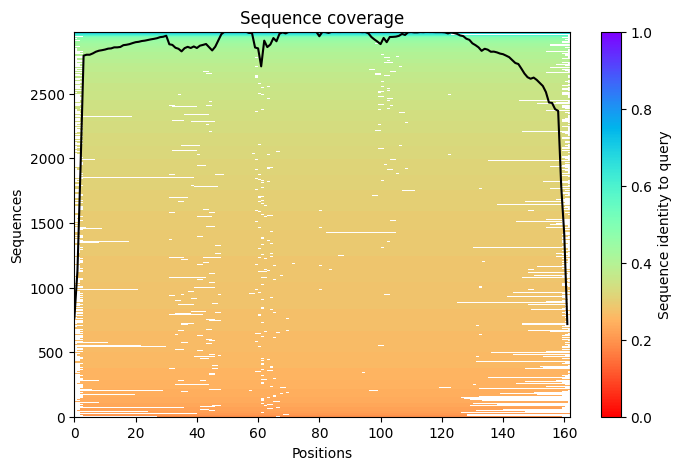

GC 10167
The following mutations will be performed : ['I146D']
Mutated residue I146D
The following mutations have been performed : ['I146D']
The cols and cols_range parameters will be overridden by the mutations parameter
Mutation before zero indexing: I146D
Mutation after zero indexing: I146D
Masked positions (mutation): 146
The MSA has been masked in the mutated positions
Mutation before zero indexing: I146D
Mutation after zero indexing: I146D
Masked positions (mutation): 146
The deletion matrix has been masked in the mutated positions
loading alphafold params 1
running prediction
seed=000 model=model_1_ptm recycle=0
seed=000 model=model_1_ptm recycle=1


In [ ]:
# @title Run AlphaMask for Most Frustrated Mutations 🧬 {"run": "auto", "display-mode":"form"}

# @markdown ## AlphaMask Mutation Analysis
# @markdown This cell takes the most frustrated mutations identified from the previous analysis and runs them through AlphaMask.
# @markdown Each mutation will be processed independently using the ITERATIVE_SINGLE_MASK_MUTATE strategy.
# @markdown
# @markdown ### What this does:
# @markdown 1. Takes each mutation identified as most frustrated
# @markdown 2. Masks that position in the MSA
# @markdown 3. Applies the specific mutation
# @markdown 4. Runs AlphaFold2 prediction
# @markdown
# @markdown ### Parameters to configure:

from IPython.display import clear_output
import os
import gc
import jax
from typing import List, Optional
from datetime import datetime

# Basic parameters
jobname_prefix = "rfah"  # @param {type:"string"}
parent_path = "/content"  # @param {type:"string"}

# @markdown ### AlphaFold2 Configuration
num_recycles = 3  # @param {type:"slider", min:1, max:20, step:1}
num_seeds = 1  # @param {type:"slider", min:1, max:20, step:1}

# @markdown ### MSA Options
msa_method = "mmseqs2"  # @param ["mmseqs2", "single_sequence", "custom_fas", "custom_a3m", "custom_sto"] {type:"string"}
# @markdown For custom MSA files (leave empty for MMseqs2):
custom_a3m_path = ""  # @param {type:"string"}

# Clear previous output
clear_output(wait=True)

print("🔍 Found Most Frustrated Mutations:")
print("-" * 50)
for res_num, data in most_frustrated_mutations.items():
    mutation_str = f"{data['native']}{res_num}{data['mutation']}"
    print(f"Position {res_num}: {data['native']} → {data['mutation']} (Frustration Index: {data['frustration_index']:.3f})")

# Create experiment instances for each mutation
experiments = []
for res_num, data in most_frustrated_mutations.items():
    mutation_str = f"{data['native']}{res_num}{data['mutation']}"

    # Create experiment instance
    experiment = MaskingExperiment(
        sequence=sequence,
        jobname_prefix=f"{jobname_prefix}_mut_{mutation_str}",
        parent_path=parent_path,
        masking_strategy="iterative_single_mask_mutate",
        positions=[res_num],  # List with single position
        num_recycles=num_recycles,
        num_seeds=num_seeds,
        msa_method=msa_method,
        custom_a3m_path=custom_a3m_path,
        mutations=mutation_str,  # Pass mutation string directly, not as a list
        run_control=False,  # Don't run control for each mutation
        run_only_control=False
    )
    experiments.append((mutation_str, experiment))

print(f"\n🚀 Preparing to run {len(experiments)} AlphaMask experiments")
print(f"📁 Results will be saved in: {parent_path}")
print(f"⚙️ Using {num_recycles} recycles and {num_seeds} seeds per prediction")
print(f"🧬 MSA method: {msa_method}")
if custom_a3m_path:
    print(f"📄 Using custom MSA from: {custom_a3m_path}")

proceed = input("\n⚠️ Ready to start processing mutations? (y/n): ")
if proceed.lower() != 'y':
    print("❌ Operation cancelled")
    raise SystemExit

# Run experiments
results = {}
for mutation_str, experiment in experiments:
    print(f"\n🔄 Processing mutation: {mutation_str}")
    print("-" * 50)

    try:
        start_time = datetime.now()
        jobname = experiment.run()
        duration = datetime.now() - start_time

        results[mutation_str] = {
            'status': 'completed',
            'jobname': jobname,
            'duration': duration
        }
        print(f"✅ Successfully completed {mutation_str} in {duration}")

    except Exception as e:
        print(f"❌ Error processing {mutation_str}: {str(e)}")
        results[mutation_str] = {
            'status': 'failed',
            'error': str(e)
        }

    # Clear memory between runs
    backend = jax.lib.xla_bridge.get_backend()
    for buf in backend.live_buffers():
        buf.delete()
    gc.collect()

# Print summary
print("\n📊 Experiment Summary:")
print("-" * 50)
successful = 0
failed = 0
for mutation_str, result in results.items():
    status = result['status']
    if status == 'completed':
        successful += 1
        duration = result['duration']
        print(f"✅ {mutation_str}: Completed in {duration} (jobname: {result['jobname']})")
    else:
        failed += 1
        print(f"❌ {mutation_str}: Failed ({result['error']})")

print(f"\n📈 Final Statistics:")
print(f"Total mutations processed: {len(results)}")
print(f"Successful: {successful}")
print(f"Failed: {failed}")

# Create results dataframe for display
results_df = pd.DataFrame([
    {
        'Mutation': mutation_str,
        'Status': result['status'],
        'Jobname': result.get('jobname', 'N/A'),
        'Duration': str(result.get('duration', 'N/A')),
        'Error': result.get('error', 'N/A')
    }
    for mutation_str, result in results.items()
])

# Display interactive results table
print("\n📋 Detailed Results Table:")
data_table.DataTable(results_df, include_index=False, num_rows_per_page=20)

# Return results dictionary for potential further use
results

# FAQ and Usage Guide

In [ ]:
# @markdown ## What's New in This Version
# @markdown - Added mutation capability with `iterative_single_mask_mutate` strategy
# @markdown - Improved MSA handling with multiple methods
# @markdown - Automatic results compression and download
# @markdown - Enhanced memory management
# @markdown - More flexible position selection

# @markdown ## Masking Strategies Explained

# @markdown ### 1. Iterative Single Position (iterative_single)
# @markdown - **What it does**: Masks one position at a time, runs AF2 for each position
# @markdown - **Usage options**:
# @markdown   - Leave "Positions to Process" empty → analyze entire sequence
# @markdown   - Enter specific positions (e.g., "1,5,10") → analyze only those positions
# @markdown - **Example**: With "1,5,10" → three predictions, each masking one position
# @markdown - **Use case**: Understanding individual residue contributions

# @markdown ### 2. Iterative Single Position with Mutation (iterative_single_mask_mutate)
# @markdown - **What it does**: Combines masking and mutation at each position
# @markdown - **Usage**:
# @markdown   - Enter positions to analyze
# @markdown   - Specify mutation (e.g., "S89R")
# @markdown - **Example**: Position "89", mutation "S89R" → predicts structure with position 89 masked and mutated
# @markdown - **Use case**: Studying mutation effects in masked contexts

# @markdown ### 3. Mask Positions (mask_positions)
# @markdown - **What it does**: Masks all specified positions simultaneously
# @markdown - **Usage**: Enter all positions to mask (e.g., "1,5,10")
# @markdown - **Example**: "1,5,10" → one prediction with all three positions masked
# @markdown - **Use case**: Analyzing combined effects of multiple positions

# @markdown ### 4. Unmask Positions (unmask_positions)
# @markdown - **What it does**: Masks everything EXCEPT specified positions
# @markdown - **Usage**: Enter positions to keep unmasked
# @markdown - **Example**: "1,5,10" in 100-residue protein → masks positions 2-4,6-9,11-100
# @markdown - **Use case**: Focusing on specific structural regions

# @markdown ## Configuration Guide

# @markdown ### Basic Parameters
# @markdown ```python
# @markdown sequence = "YOUR_SEQUENCE"  # Input protein sequence
# @markdown jobname_prefix = "experiment1"  # Prefix for output files
# @markdown masking_strategy = "iterative_single"  # Choose strategy
# @markdown positions_str = "1,5,10"  # Positions to process (optional)
# @markdown ```

# @markdown ### Advanced Parameters
# @markdown ```python
# @markdown num_recycles = 6  # Number of recycles (3-20)
# @markdown num_seeds = 6  # Number of seeds (3-20)
# @markdown msa_method = "mmseqs2"  # MSA generation method
# @markdown run_control = True  # Run unmasked prediction
# @markdown ```

# @markdown ## Common Questions

# @markdown ### Q: How do I set up my first experiment?
# @markdown A: Basic setup steps:
# @markdown 1. Paste your sequence
# @markdown 2. Choose masking strategy
# @markdown 3. Set positions (if needed)
# @markdown 4. Run the cell
# @markdown Default parameters work well for most cases

# @markdown ### Q: Which MSA method should I use?
# @markdown A: Available options:
# @markdown - `mmseqs2`: Best for most cases
# @markdown - `single_sequence`: Quick testing
# @markdown - `custom_a3m`: Use existing alignment
# @markdown - `custom_fas`: Use FASTA file
# @markdown - `custom_sto`: Use Stockholm file

# @markdown ### Q: How long will it take?
# @markdown A: Approximate times per prediction:
# @markdown - Basic run (3 recycles): ~15-20 minutes
# @markdown - Standard run (6 recycles): ~25-30 minutes
# @markdown - High-accuracy (12 recycles): ~45-60 minutes
# @markdown - Total time = (predictions × time per prediction)

# @markdown ### Q: Memory issues?
# @markdown A: Try these solutions:
# @markdown ```python
# @markdown num_recycles = 3  # Reduce recycles
# @markdown num_seeds = 3  # Reduce seeds
# @markdown msa_method = "single_sequence"  # Simpler MSA
# @markdown ```

# @markdown ### Q: Recommended settings for different scenarios?
# @markdown A: Common configurations:
# @markdown ```python
# @markdown # Quick test
# @markdown num_recycles = 3
# @markdown num_seeds = 3
# @markdown msa_method = "single_sequence"
# @markdown
# @markdown # Standard run
# @markdown num_recycles = 6
# @markdown num_seeds = 6
# @markdown msa_method = "mmseqs2"
# @markdown
# @markdown # High accuracy
# @markdown num_recycles = 12
# @markdown num_seeds = 12
# @markdown msa_method = "mmseqs2"
# @markdown ```

# @markdown ### Q: Where are my results?
# @markdown A: Results are:
# @markdown 1. Saved in your specified parent_path
# @markdown 2. Automatically zipped
# @markdown 3. Downloaded to your computer
# @markdown 4. Named: [jobname_prefix]_[strategy]_[positions].zip

# @markdown ### Q: Should I run control predictions?
# @markdown A: Recommended when:
# @markdown - First time running sequence
# @markdown - Comparing masked vs unmasked
# @markdown - Validating mutations
# @markdown Skip if you already have unmasked prediction

# @markdown ## Mutation Analysis Guide

# @markdown ### Example mutation workflow:
# @markdown ```python
# @markdown # Single mutation
# @markdown masking_strategy = "iterative_single_mask_mutate"
# @markdown positions_str = "89"
# @markdown mutations = "S89R"
# @markdown
# @markdown # Run with validation
# @markdown run_control = True  # Compare with wild-type
# @markdown ```

# @markdown ### Tips for mutation analysis:
# @markdown - Always run control for comparison
# @markdown - Use consistent parameters between runs
# @markdown - Consider running multiple seeds
# @markdown - Check surrounding residues

# @markdown ## Advanced Usage

# @markdown ### Example: Regional analysis
# @markdown ```python
# @markdown # Analyze binding site (positions 10-20)
# @markdown masking_strategy = "unmask_positions"
# @markdown positions_str = "10,11,12,13,14,15,16,17,18,19,20"
# @markdown ```

# @markdown ### Example: Multiple positions
# @markdown ```python
# @markdown # Mask multiple specific positions
# @markdown masking_strategy = "mask_positions"
# @markdown positions_str = "1,5,10,15,20"
# @markdown ```

# @markdown ### Example: High-throughput scanning
# @markdown ```python
# @markdown # Scan entire sequence
# @markdown masking_strategy = "iterative_single"
# @markdown positions_str = ""  # Empty for full sequence
# @markdown ```